FOOD PRICE FORECASTING
MODEL EVALUATION

Loading forecasting outputs...

Files loaded successfully.

Model comparison rows:      4
Crop performance rows:      9
Price-band rows:            4
Test prediction rows:       243

BEST MODEL

Best machine learning model: Extra_Trees
MAE:   ₹78.74
RMSE:  ₹134.46
MAPE:  1.99%
SMAPE: 1.97%
R²:    0.9941

Independent prediction-file validation:
  MAE:  ₹78.74
  RMSE: ₹134.46
  R²:   0.9941
✓ Prediction file matches the selected model metrics.

MODEL COMPARISON


,Model,MAE,RMSE,MAPE,SMAPE,R2
0,Extra_Trees,78.7358,134.4564,1.9872,1.9699,0.9941
1,Hist_Gradient_Boosting,99.8696,211.6214,1.9594,1.9227,0.9855
2,Random_Forest,231.7966,346.2952,7.2151,7.0824,0.9611
3,Naive_Last_Month,271.2243,458.6914,10.0720,9.5730,0.9317



IMPROVEMENT OVER NAIVE BASELINE

Baseline RMSE: ₹458.69
Best model RMSE: ₹134.46
RMSE improvement: 70.69%

Baseline MAE: ₹271.22
Best model MAE: ₹78.74
MAE improvement: 70.97%

ACTUAL VS PREDICTED PRICE


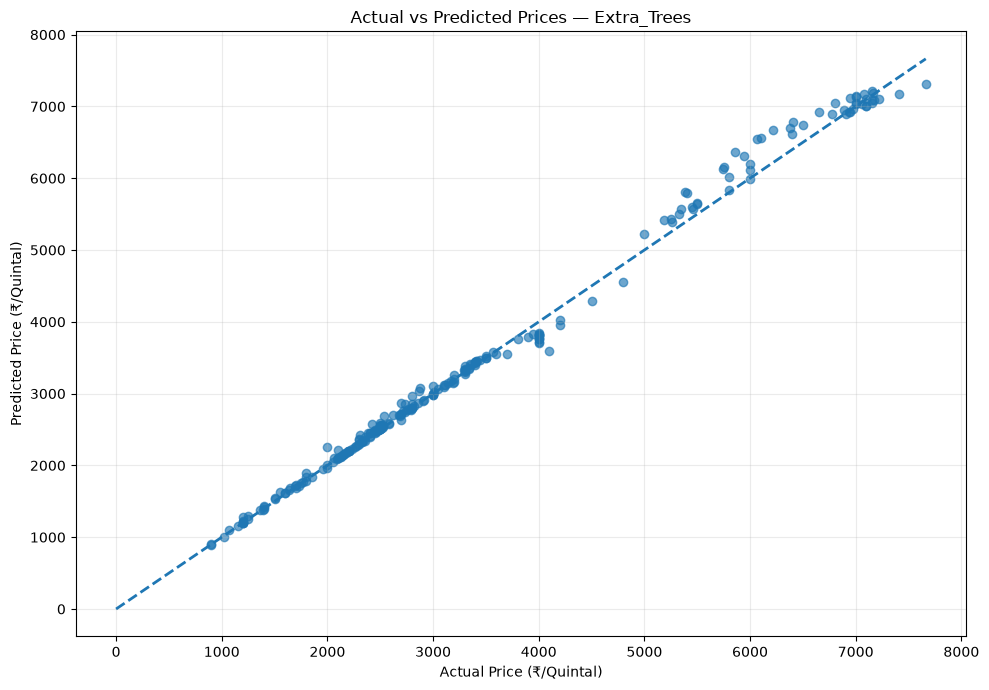


TEST-PERIOD FORECAST PERFORMANCE


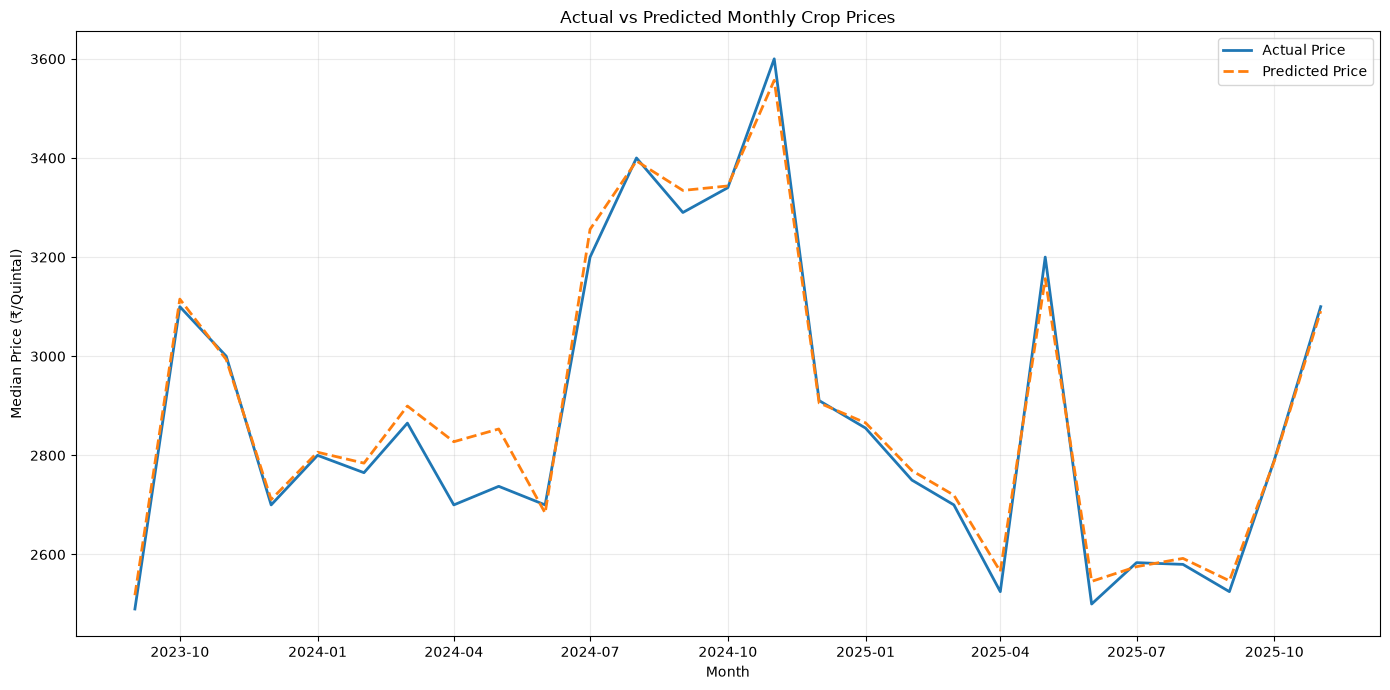


CROP-LEVEL MODEL PERFORMANCE


,Crop,Test_Observations,MAE,RMSE,MAPE,SMAPE,R2
0,Maize,27,3.4725,5.1849,0.1738,0.1735,0.9990
1,Wheat,27,10.1475,12.7435,0.4002,0.3991,0.9929
2,Rice,27,19.6552,24.2583,0.5908,0.5889,0.9797
3,Potato,27,23.2173,33.1057,1.4910,1.4723,0.9964
4,Jowar/Sorghum,27,81.5651,100.0374,2.9540,2.9021,0.9597
5,Cotton,27,106.0085,139.3837,1.5082,1.5045,0.5931
6,Onion,27,91.4874,143.1790,3.2720,3.2652,0.9808
7,Banana,27,110.3860,147.8647,2.9345,2.9905,0.9279
8,Groundnut,27,262.6826,298.3849,4.5605,4.4328,0.4237


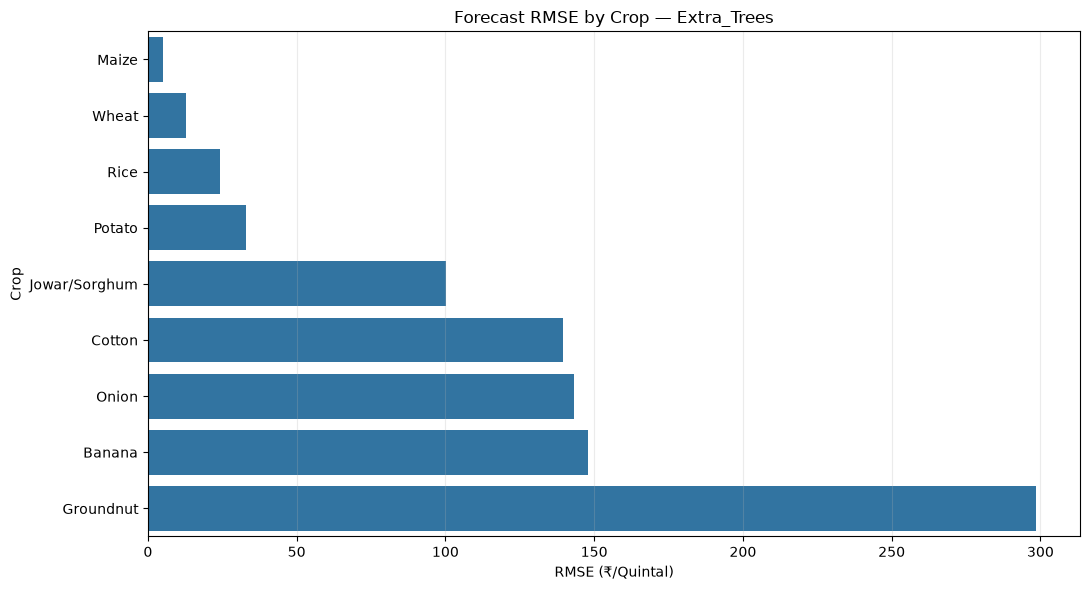

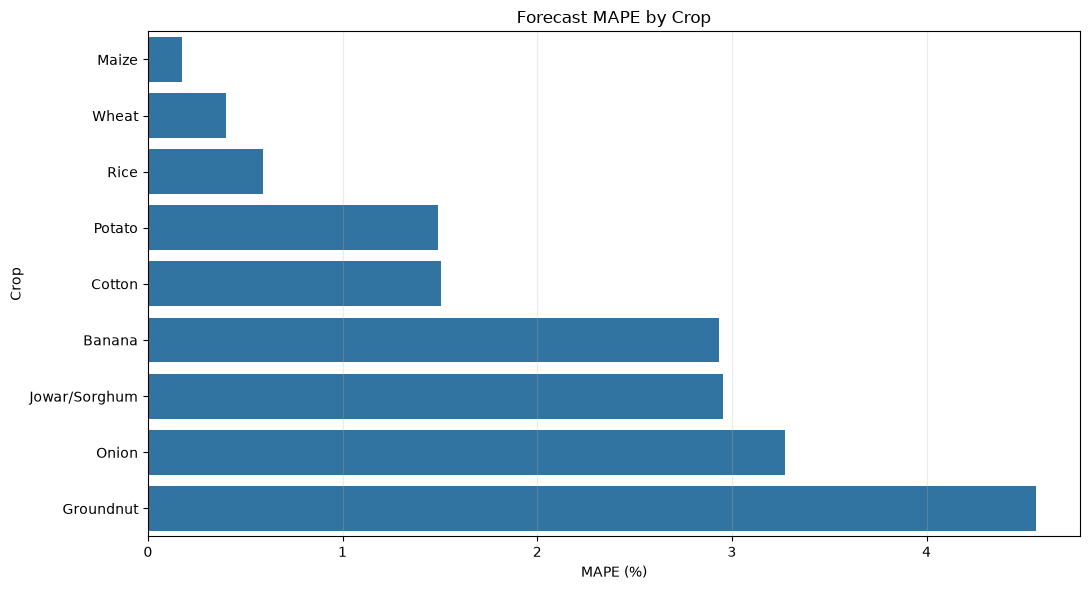

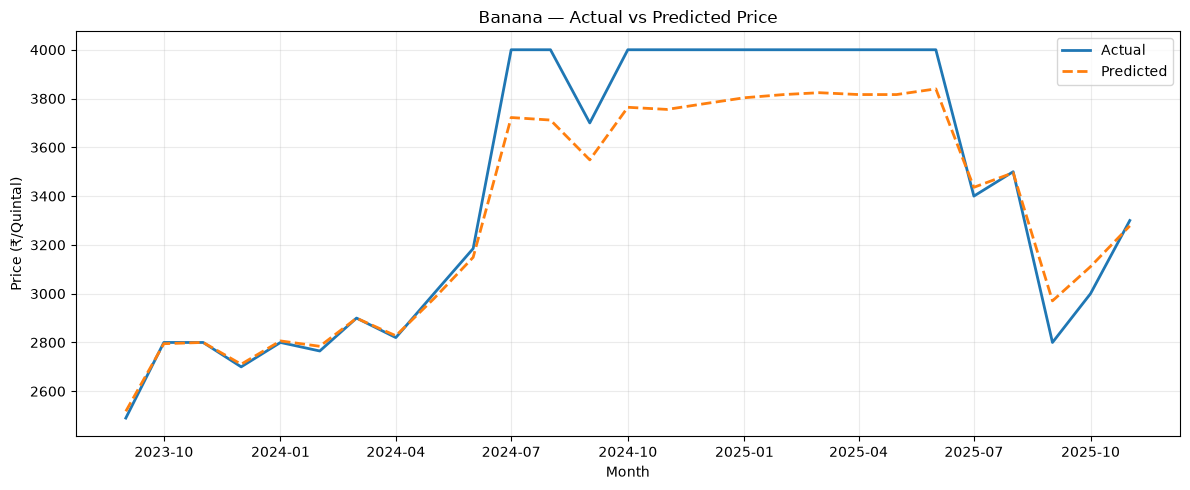

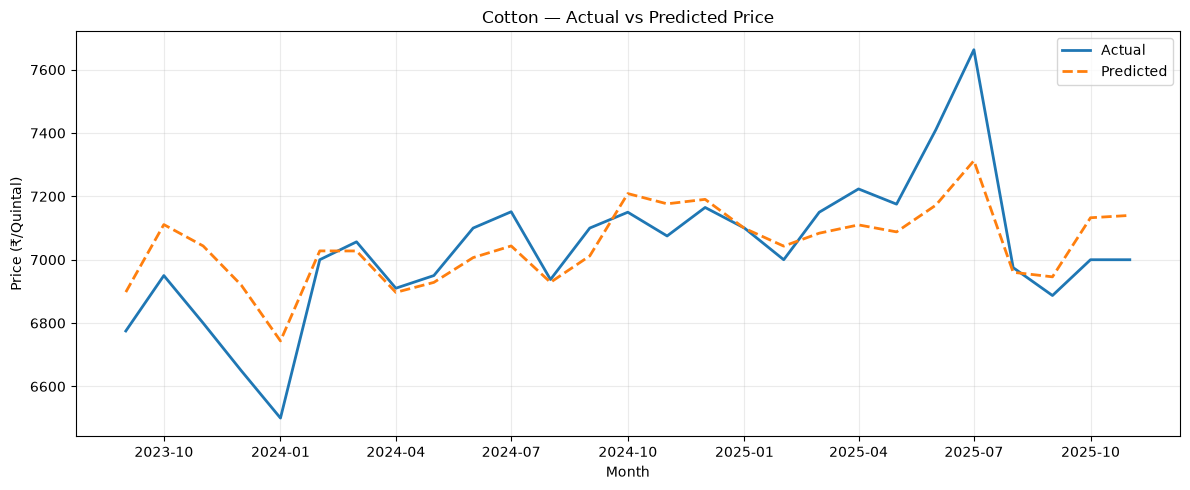

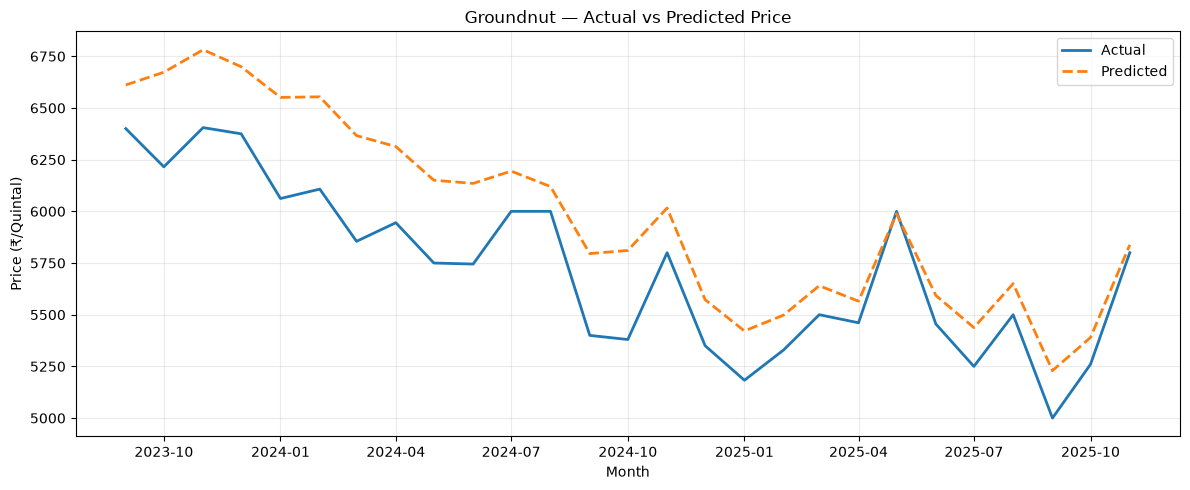

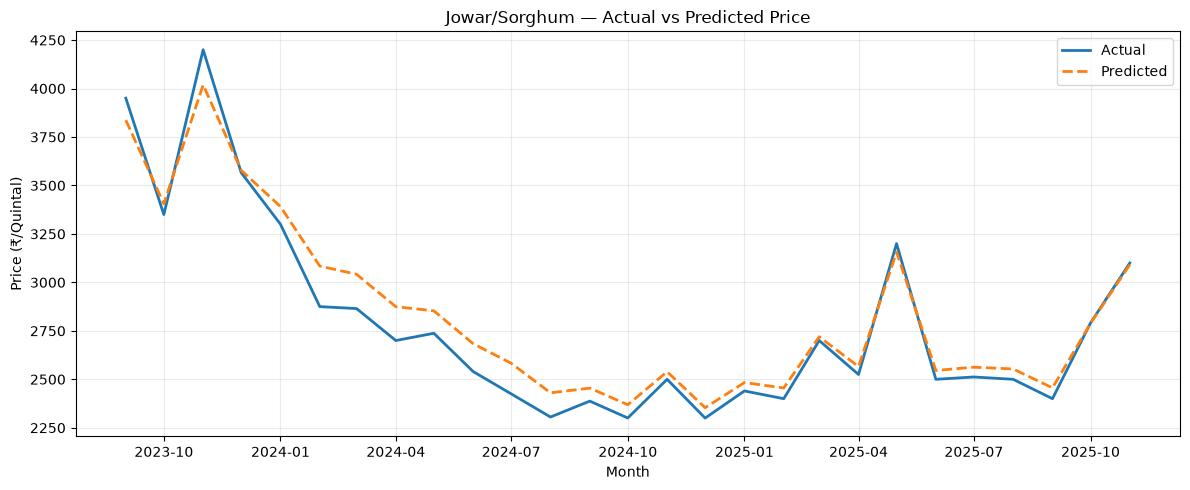

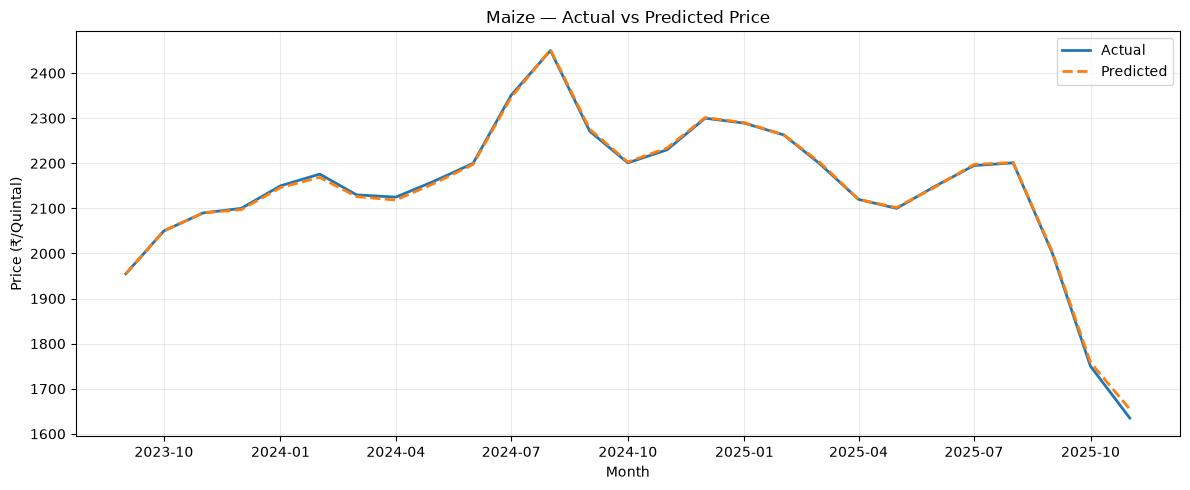

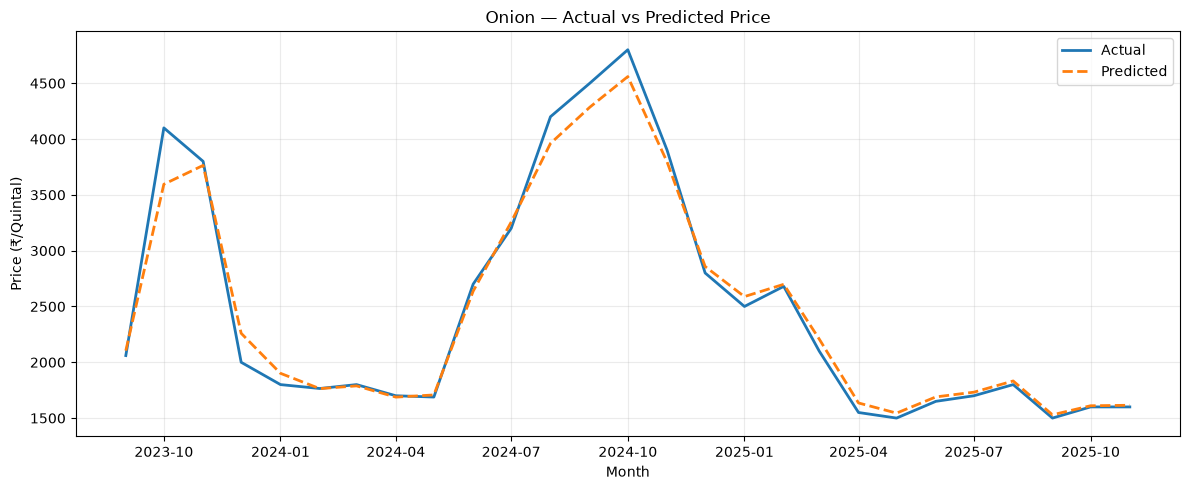

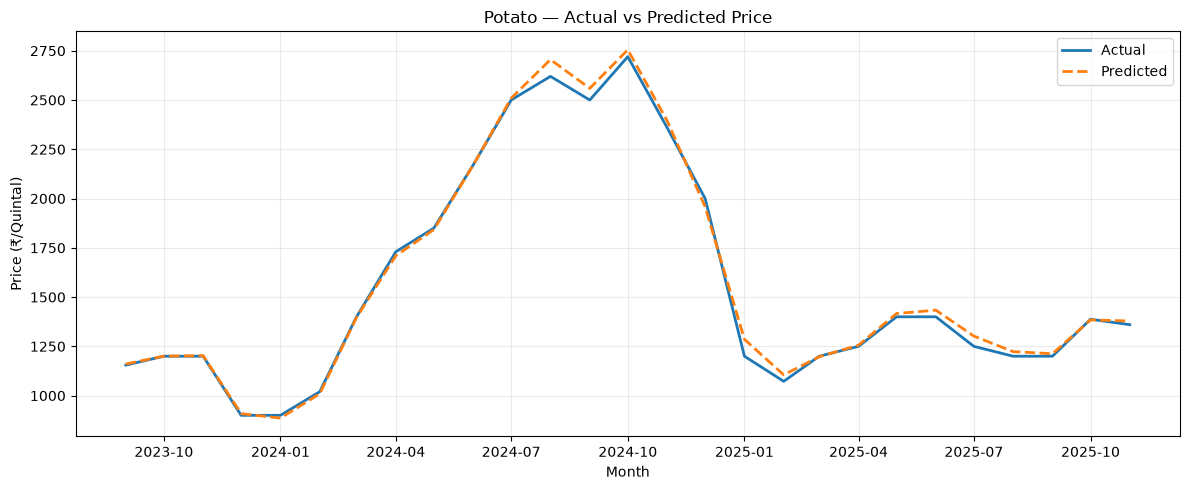

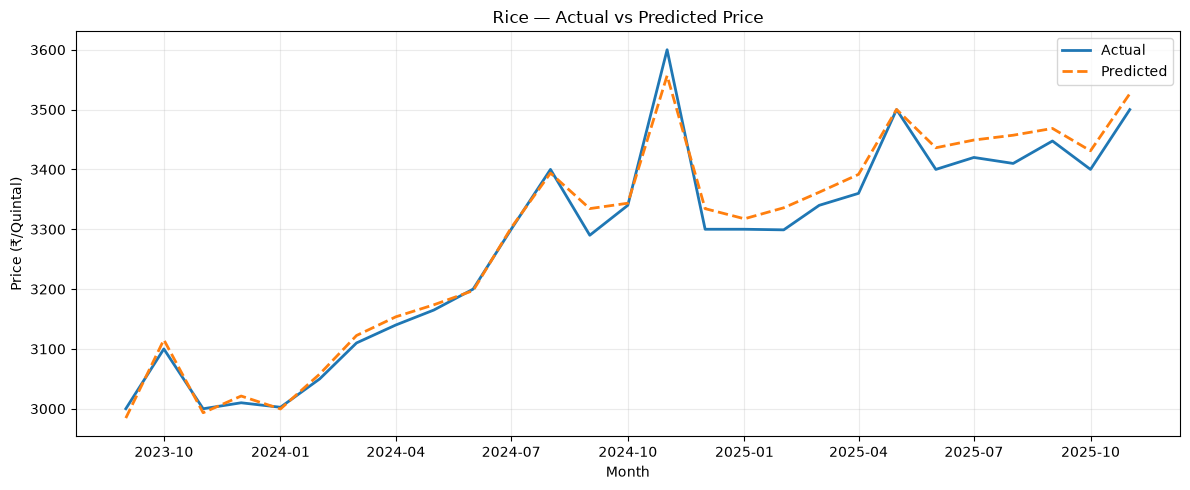

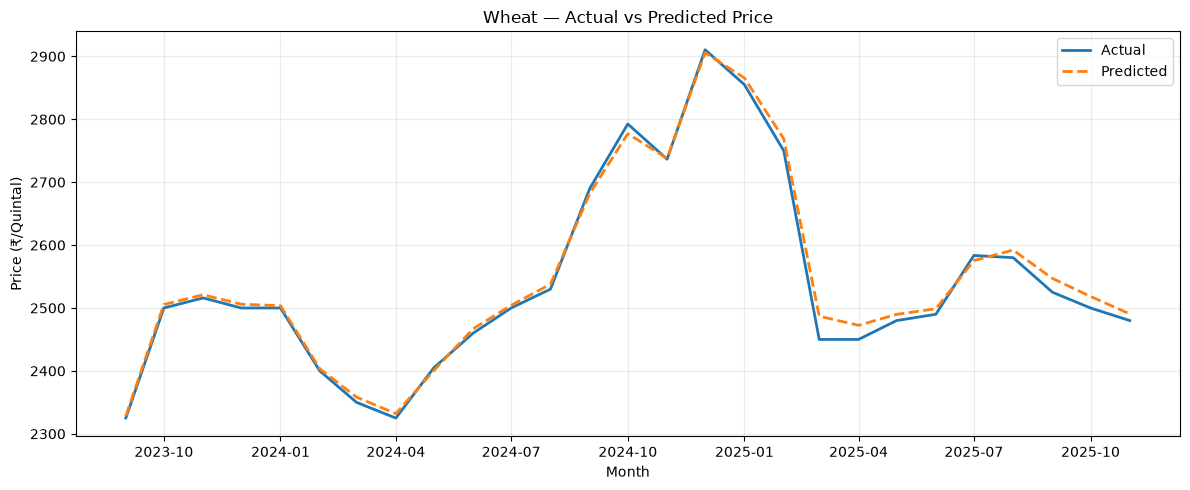


PRICE-BAND PERFORMANCE


,Price_Band,Test_Observations,MAE,RMSE,MAPE,SMAPE,R2
0,"< ₹2,000",39,28.8868,52.9000,1.8598,1.8178,0.9704
1,"₹2,000–₹5,000",151,54.8412,96.5683,1.6629,1.6686,0.9769
2,"₹5,000–₹7,500",52,180.2854,230.0942,2.9749,2.9065,0.8900
3,"₹7,500–₹10,000",1,350.3604,350.3604,4.5721,4.6791,NaN


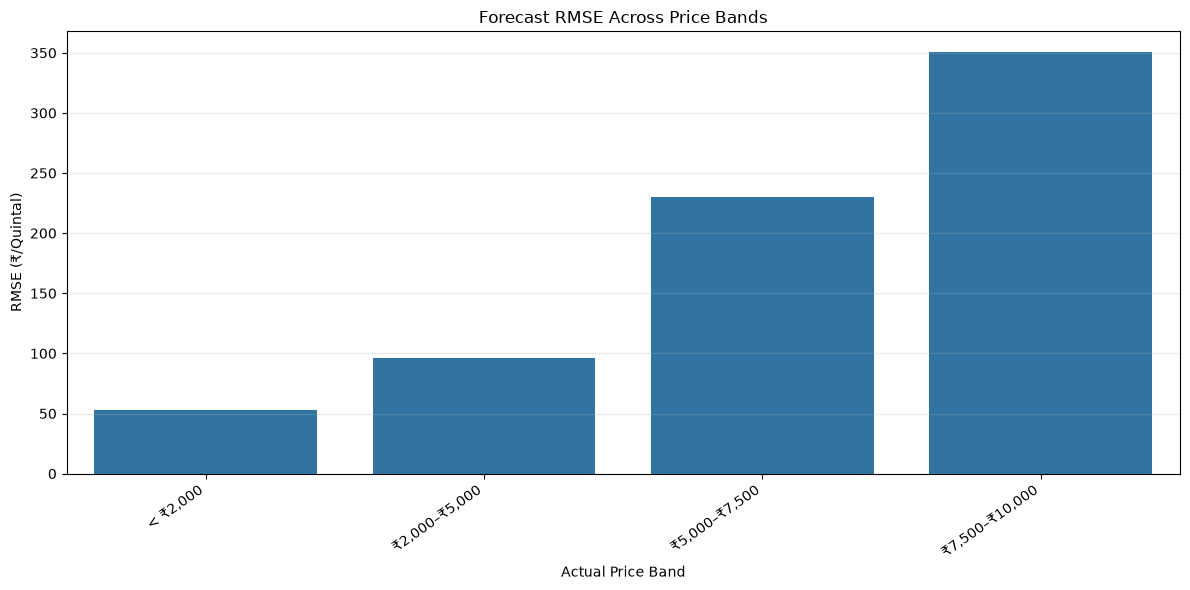


RESIDUAL ANALYSIS


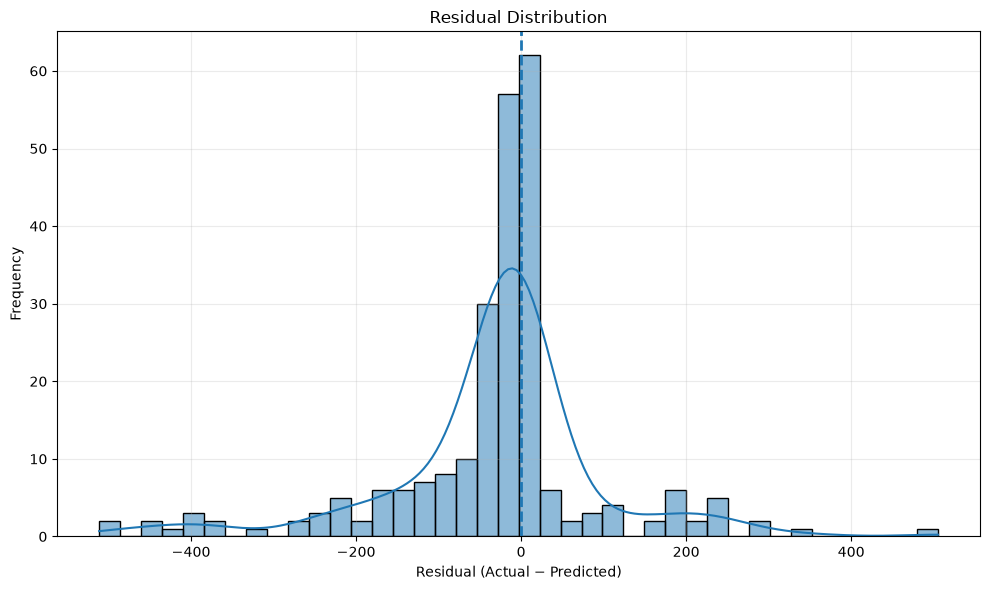

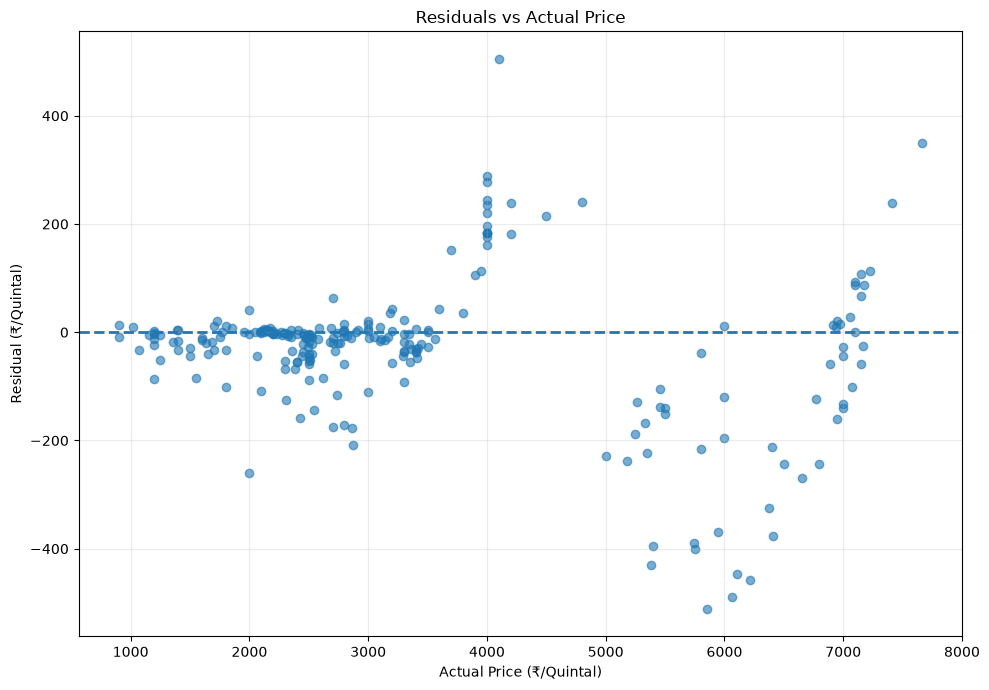

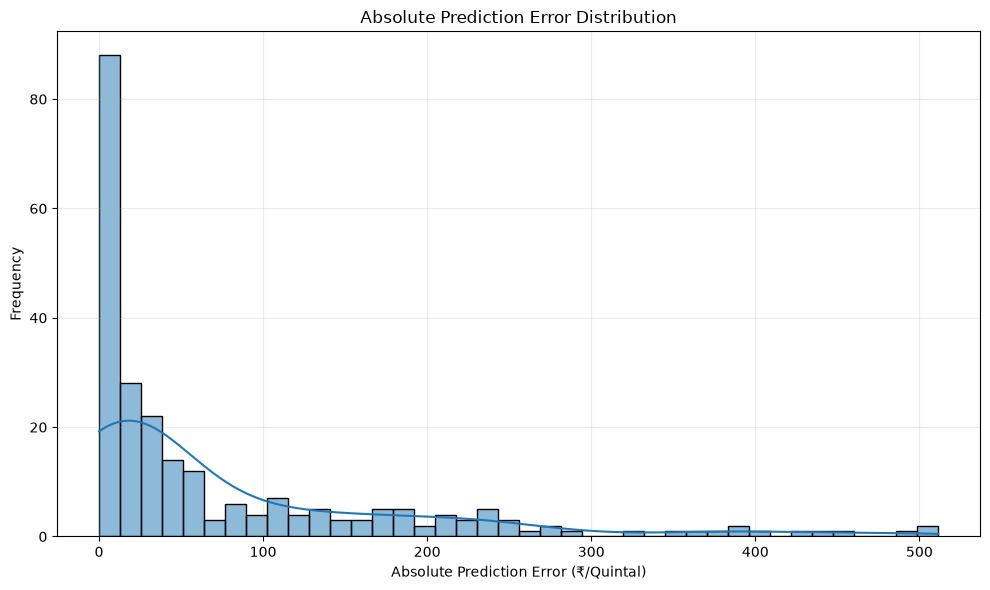

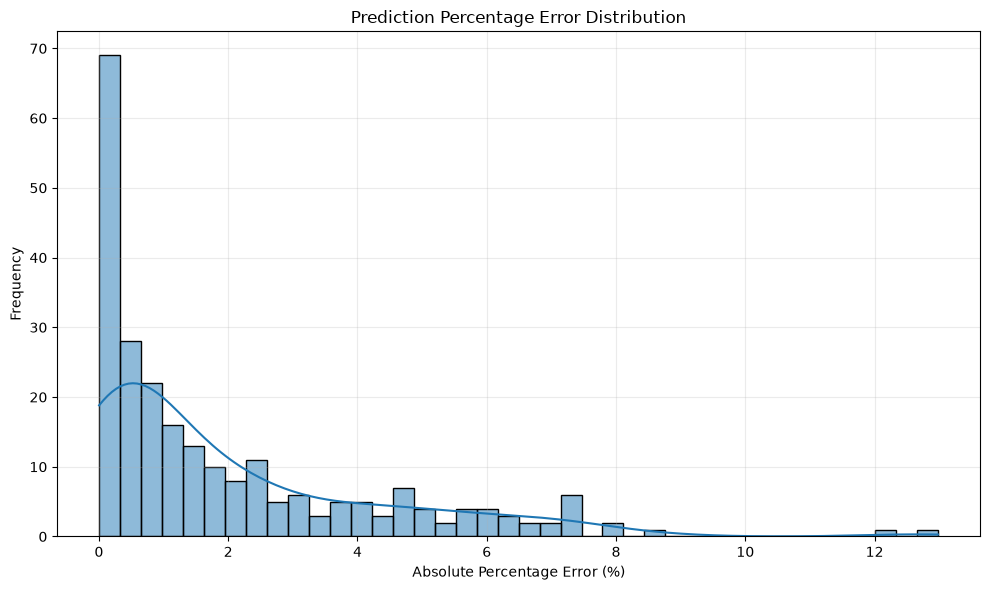


20 LARGEST PREDICTION ERRORS


,Crop,Month_Start,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error,Residual
60,Groundnut,2024-03-01,5855.00,6366.36,511.36,8.73,-511.36
136,Onion,2023-10-01,4100.00,3594.76,505.24,12.32,505.24
58,Groundnut,2024-01-01,6062.00,6551.13,489.13,8.07,-489.13
55,Groundnut,2023-10-01,6215.25,6672.93,457.68,7.36,-457.68
59,Groundnut,2024-02-01,6107.50,6553.87,446.37,7.31,-446.37
67,Groundnut,2024-10-01,5380.00,5810.78,430.78,8.01,-430.78
62,Groundnut,2024-05-01,5750.00,6150.45,400.45,6.96,-400.45
66,Groundnut,2024-09-01,5400.00,5795.58,395.58,7.33,-395.58
63,Groundnut,2024-06-01,5745.00,6135.15,390.15,6.79,-390.15
56,Groundnut,2023-11-01,6405.00,6781.61,376.61,5.88,-376.61



CROP PERFORMANCE SUMMARY

Lowest RMSE crop: Maize
RMSE: ₹5.18

Highest RMSE crop: Groundnut
RMSE: ₹298.38

INDEPENDENT PREDICTION ERROR CHECK

Mean residual: ₹-30.39
Median residual: ₹-9.87
Mean absolute error: ₹78.74
RMSE: ₹134.46
R²: 0.9941

MODEL EVALUATION COMPLETE

Best model:                 Extra_Trees
Test observations:         243
Number of crops:           9

MAE:                       ₹78.74
RMSE:                      ₹134.46
MAPE:                      1.99%
SMAPE:                     1.97%
R²:                        0.9941

Mean residual:             ₹-30.39
Median residual:           ₹-9.87

RMSE improvement vs naive: 70.69%
MAE improvement vs naive:  70.97%

Evaluation files saved:
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\outputs\evaluation\model_comparison_evaluation.csv
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\outputs\evaluation\crop_level_performance.csv
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\F

In [1]:
# ============================================================
# 06_MODEL_EVALUATION
# FOOD PRICE FORECASTING MODEL EVALUATION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "forecasting"
)

EVALUATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD FORECASTING OUTPUTS
# ============================================================

print("=" * 70)
print("FOOD PRICE FORECASTING")
print("MODEL EVALUATION")
print("=" * 70)

print("\nLoading forecasting outputs...")


model_comparison = pd.read_csv(
    OUTPUT_DIR / "model_comparison.csv"
)

crop_performance = pd.read_csv(
    OUTPUT_DIR / "crop_model_performance.csv"
)

price_band_performance = pd.read_csv(
    OUTPUT_DIR / "price_band_model_performance.csv"
)

test_predictions = pd.read_csv(
    OUTPUT_DIR / "test_predictions.csv"
)


test_predictions["Month_Start"] = pd.to_datetime(
    test_predictions["Month_Start"],
    errors="coerce"
)


test_predictions = (
    test_predictions
    .sort_values(
        ["Crop", "Month_Start"]
    )
    .reset_index(drop=True)
)


print("\nFiles loaded successfully.")

print(
    f"\nModel comparison rows:      {len(model_comparison):,}"
)

print(
    f"Crop performance rows:      {len(crop_performance):,}"
)

print(
    f"Price-band rows:            {len(price_band_performance):,}"
)

print(
    f"Test prediction rows:       {len(test_predictions):,}"
)


# ============================================================
# 3. VALIDATE REQUIRED COLUMNS
# ============================================================

required_prediction_columns = [
    "Crop",
    "Month_Start",
    "Actual_Price",
    "Predicted_Price",
    "Absolute_Error",
    "Percentage_Error"
]


missing_columns = [
    col
    for col in required_prediction_columns
    if col not in test_predictions.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required prediction columns: "
        f"{missing_columns}"
    )


test_predictions = test_predictions.dropna(
    subset=[
        "Actual_Price",
        "Predicted_Price"
    ]
).copy()

if test_predictions.empty:
    raise ValueError(
        "No valid actual/predicted observations remain after cleaning."
    )

for col in ["Actual_Price", "Predicted_Price"]:
    if not np.isfinite(
        pd.to_numeric(test_predictions[col], errors="coerce")
    ).all():
        raise ValueError(
            f"Non-finite values detected in {col}."
        )

if (test_predictions["Actual_Price"] <= 0).any():
    raise ValueError(
        "Actual test prices must be positive for percentage-error evaluation."
    )


# ============================================================
# 4. CALCULATE RESIDUALS
# ============================================================

test_predictions["Residual"] = (
    test_predictions["Actual_Price"]
    -
    test_predictions["Predicted_Price"]
)


test_predictions["Absolute_Residual"] = (
    np.abs(
        test_predictions["Residual"]
    )
)


test_predictions["Squared_Error"] = (
    test_predictions["Residual"] ** 2
)

duplicate_prediction_keys = (
    test_predictions
    .duplicated(
        subset=["Crop", "Month_Start"],
        keep=False
    )
)

if duplicate_prediction_keys.any():
    raise ValueError(
        "Duplicate Crop/Month prediction rows detected."
    )

if test_predictions["Month_Start"].isna().any():
    raise ValueError(
        "Invalid Month_Start values detected in test predictions."
    )


# ============================================================
# 5. IDENTIFY BEST MACHINE LEARNING MODEL
# ============================================================

ml_comparison = model_comparison[
    model_comparison["Model"] != "Naive_Last_Month"
].copy()


ml_comparison = ml_comparison.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)


best_model_name = (
    ml_comparison
    .iloc[0]["Model"]
)


best_model_metrics = (
    ml_comparison
    .iloc[0]
)


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)


print(
    f"\nBest machine learning model: "
    f"{best_model_name}"
)


print(
    f"MAE:   ₹{best_model_metrics['MAE']:,.2f}"
)

print(
    f"RMSE:  ₹{best_model_metrics['RMSE']:,.2f}"
)

print(
    f"MAPE:  {best_model_metrics['MAPE']:.2f}%"
)

print(
    f"SMAPE: {best_model_metrics['SMAPE']:.2f}%"
)

print(
    f"R²:    {best_model_metrics['R2']:.4f}"
)

# Confirm that the prediction file reproduces the selected model's
# independently reported test metrics.
independent_mae_check = mean_absolute_error(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"]
)

independent_rmse_check = np.sqrt(
    mean_squared_error(
        test_predictions["Actual_Price"],
        test_predictions["Predicted_Price"]
    )
)

independent_r2_check = r2_score(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"]
)

print("\nIndependent prediction-file validation:")
print(f"  MAE:  ₹{independent_mae_check:,.2f}")
print(f"  RMSE: ₹{independent_rmse_check:,.2f}")
print(f"  R²:   {independent_r2_check:.4f}")

if not np.isclose(
    independent_mae_check,
    best_model_metrics["MAE"],
    rtol=0.01,
    atol=0.01
):
    raise ValueError(
        "Prediction-file MAE does not match the selected model's reported MAE."
    )

if not np.isclose(
    independent_rmse_check,
    best_model_metrics["RMSE"],
    rtol=0.01,
    atol=0.01
):
    raise ValueError(
        "Prediction-file RMSE does not match the selected model's reported RMSE."
    )

if not np.isclose(
    independent_r2_check,
    best_model_metrics["R2"],
    rtol=0.001,
    atol=0.001
):
    raise ValueError(
        "Prediction-file R² does not match the selected model's reported R²."
    )

print("✓ Prediction file matches the selected model metrics.")


# ============================================================
# 6. MODEL COMPARISON TABLE
# ============================================================

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)


display(
    model_comparison.round(4)
)


model_comparison.to_csv(
    EVALUATION_DIR
    / "model_comparison_evaluation.csv",
    index=False
)


# ============================================================
# 7. CALCULATE BASELINE IMPROVEMENT
# ============================================================

baseline_row = model_comparison[
    model_comparison["Model"]
    ==
    "Naive_Last_Month"
]


if len(baseline_row) > 0:

    baseline_rmse = (
        baseline_row.iloc[0]["RMSE"]
    )

    baseline_mae = (
        baseline_row.iloc[0]["MAE"]
    )

    best_rmse = (
        best_model_metrics["RMSE"]
    )

    best_mae = (
        best_model_metrics["MAE"]
    )

    rmse_improvement = (
        (
            baseline_rmse
            -
            best_rmse
        )
        /
        baseline_rmse
        *
        100
    )

    mae_improvement = (
        (
            baseline_mae
            -
            best_mae
        )
        /
        baseline_mae
        *
        100
    )

    print("\n" + "=" * 70)
    print("IMPROVEMENT OVER NAIVE BASELINE")
    print("=" * 70)

    print(
        f"\nBaseline RMSE: "
        f"₹{baseline_rmse:,.2f}"
    )

    print(
        f"Best model RMSE: "
        f"₹{best_rmse:,.2f}"
    )

    print(
        f"RMSE improvement: "
        f"{rmse_improvement:.2f}%"
    )

    print(
        f"\nBaseline MAE: "
        f"₹{baseline_mae:,.2f}"
    )

    print(
        f"Best model MAE: "
        f"₹{best_mae:,.2f}"
    )

    print(
        f"MAE improvement: "
        f"{mae_improvement:.2f}%"
    )

else:

    rmse_improvement = np.nan
    mae_improvement = np.nan


# ============================================================
# 8. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED PRICE")
print("=" * 70)


plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"],
    alpha=0.65
)


max_value = max(
    test_predictions["Actual_Price"].max(),
    test_predictions["Predicted_Price"].max()
)


plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Price (₹/Quintal)"
)

plt.ylabel(
    "Predicted Price (₹/Quintal)"
)

plt.title(
    f"Actual vs Predicted Prices — {best_model_name}"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 9. OVERALL TEST-PERIOD TIME SERIES
# ============================================================

print("\n" + "=" * 70)
print("TEST-PERIOD FORECAST PERFORMANCE")
print("=" * 70)


overall_monthly = (
    test_predictions
    .groupby("Month_Start")
    .agg(
        Actual_Price=("Actual_Price", "median"),
        Predicted_Price=("Predicted_Price", "median")
    )
    .reset_index()
)


plt.figure(
    figsize=(14, 7)
)


plt.plot(
    overall_monthly["Month_Start"],
    overall_monthly["Actual_Price"],
    linewidth=2,
    label="Actual Price"
)


plt.plot(
    overall_monthly["Month_Start"],
    overall_monthly["Predicted_Price"],
    linewidth=2,
    linestyle="--",
    label="Predicted Price"
)


plt.xlabel(
    "Month"
)

plt.ylabel(
    "Median Price (₹/Quintal)"
)

plt.title(
    "Actual vs Predicted Monthly Crop Prices"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "overall_actual_vs_predicted_time_series.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 10. CROP-LEVEL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("CROP-LEVEL MODEL PERFORMANCE")
print("=" * 70)


display(
    crop_performance.round(4)
)


crop_performance.to_csv(
    EVALUATION_DIR
    / "crop_level_performance.csv",
    index=False
)


# ============================================================
# 11. CROP-LEVEL RMSE
# ============================================================

plt.figure(
    figsize=(11, 6)
)


crop_plot = (
    crop_performance
    .sort_values("RMSE")
)


sns.barplot(
    data=crop_plot,
    x="RMSE",
    y="Crop"
)


plt.xlabel(
    "RMSE (₹/Quintal)"
)

plt.ylabel(
    "Crop"
)

plt.title(
    f"Forecast RMSE by Crop — {best_model_name}"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "crop_rmse.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. CROP-LEVEL MAPE
# ============================================================

plt.figure(
    figsize=(11, 6)
)


crop_mape_plot = (
    crop_performance
    .sort_values("MAPE")
)


sns.barplot(
    data=crop_mape_plot,
    x="MAPE",
    y="Crop"
)


plt.xlabel(
    "MAPE (%)"
)

plt.ylabel(
    "Crop"
)

plt.title(
    "Forecast MAPE by Crop"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "crop_mape.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 13. CROP-WISE ACTUAL VS PREDICTED
# ============================================================

crop_prediction_summary = (
    test_predictions
    .groupby(
        ["Crop", "Month_Start"]
    )
    .agg(
        Actual_Price=("Actual_Price", "median"),
        Predicted_Price=("Predicted_Price", "median")
    )
    .reset_index()
)


crop_prediction_summary.to_csv(
    EVALUATION_DIR
    / "crop_monthly_predictions.csv",
    index=False
)


for crop in sorted(
    crop_prediction_summary["Crop"].unique()
):

    crop_data = crop_prediction_summary[
        crop_prediction_summary["Crop"] == crop
    ].copy()

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        crop_data["Month_Start"],
        crop_data["Actual_Price"],
        linewidth=2,
        label="Actual"
    )

    plt.plot(
        crop_data["Month_Start"],
        crop_data["Predicted_Price"],
        linewidth=2,
        linestyle="--",
        label="Predicted"
    )

    plt.title(
        f"{crop} — Actual vs Predicted Price"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Price (₹/Quintal)"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    safe_crop_name = (
        crop
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        EVALUATION_DIR
        / f"{safe_crop_name}_actual_vs_predicted.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 14. PRICE-BAND PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("PRICE-BAND PERFORMANCE")
print("=" * 70)


display(
    price_band_performance.round(4)
)


price_band_performance.to_csv(
    EVALUATION_DIR
    / "price_band_performance.csv",
    index=False
)


# ============================================================
# 15. PRICE-BAND RMSE
# ============================================================

plt.figure(
    figsize=(12, 6)
)


sns.barplot(
    data=price_band_performance,
    x="Price_Band",
    y="RMSE"
)


plt.xlabel(
    "Actual Price Band"
)

plt.ylabel(
    "RMSE (₹/Quintal)"
)

plt.title(
    "Forecast RMSE Across Price Bands"
)


plt.xticks(
    rotation=35,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "price_band_rmse.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. RESIDUAL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("RESIDUAL ANALYSIS")
print("=" * 70)


plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    test_predictions["Residual"],
    bins=40,
    kde=True
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Residual (Actual − Predicted)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Residual Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 17. RESIDUALS VS ACTUAL PRICE
# ============================================================

plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    test_predictions["Actual_Price"],
    test_predictions["Residual"],
    alpha=0.60
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Price (₹/Quintal)"
)

plt.ylabel(
    "Residual (₹/Quintal)"
)

plt.title(
    "Residuals vs Actual Price"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "residuals_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 18. ABSOLUTE ERROR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    test_predictions["Absolute_Error"],
    bins=40,
    kde=True
)


plt.xlabel(
    "Absolute Prediction Error (₹/Quintal)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Absolute Prediction Error Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "absolute_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 19. PERCENTAGE ERROR DISTRIBUTION
# ============================================================

percentage_error_clean = (
    test_predictions["Percentage_Error"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)


percentage_error_clean = (
    percentage_error_clean[
        percentage_error_clean <= 100
    ]
)


plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    percentage_error_clean,
    bins=40,
    kde=True
)


plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Prediction Percentage Error Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "percentage_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 20. LARGEST PREDICTION ERRORS
# ============================================================

print("\n" + "=" * 70)
print("20 LARGEST PREDICTION ERRORS")
print("=" * 70)


largest_errors = (
    test_predictions
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(20)
    [
        [
            "Crop",
            "Month_Start",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Percentage_Error",
            "Residual"
        ]
    ]
)


display(
    largest_errors.round(2)
)


largest_errors.to_csv(
    EVALUATION_DIR
    / "largest_prediction_errors.csv",
    index=False
)


# ============================================================
# 21. BEST AND WORST CROP PERFORMANCE
# ============================================================

best_crop_by_rmse = (
    crop_performance
    .sort_values("RMSE")
    .iloc[0]
)


worst_crop_by_rmse = (
    crop_performance
    .sort_values("RMSE", ascending=False)
    .iloc[0]
)


print("\n" + "=" * 70)
print("CROP PERFORMANCE SUMMARY")
print("=" * 70)


print(
    f"\nLowest RMSE crop: "
    f"{best_crop_by_rmse['Crop']}"
)

print(
    f"RMSE: "
    f"₹{best_crop_by_rmse['RMSE']:,.2f}"
)


print(
    f"\nHighest RMSE crop: "
    f"{worst_crop_by_rmse['Crop']}"
)

print(
    f"RMSE: "
    f"₹{worst_crop_by_rmse['RMSE']:,.2f}"
)


# ============================================================
# 22. ERROR SUMMARY
# ============================================================

mean_residual = (
    test_predictions["Residual"].mean()
)


median_residual = (
    test_predictions["Residual"].median()
)


mean_absolute_error_value = (
    test_predictions["Absolute_Error"].mean()
)


rmse_value = np.sqrt(
    np.mean(
        test_predictions["Residual"] ** 2
    )
)


r2_value = r2_score(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"]
)


print("\n" + "=" * 70)
print("INDEPENDENT PREDICTION ERROR CHECK")
print("=" * 70)


print(
    f"\nMean residual: "
    f"₹{mean_residual:,.2f}"
)


print(
    f"Median residual: "
    f"₹{median_residual:,.2f}"
)


print(
    f"Mean absolute error: "
    f"₹{mean_absolute_error_value:,.2f}"
)


print(
    f"RMSE: "
    f"₹{rmse_value:,.2f}"
)


print(
    f"R²: "
    f"{r2_value:.4f}"
)


# ============================================================
# 23. SAVE RESIDUAL DATA
# ============================================================

residual_output = test_predictions[
    [
        "Crop",
        "Month_Start",
        "Actual_Price",
        "Predicted_Price",
        "Residual",
        "Absolute_Residual",
        "Percentage_Error"
    ]
].copy()


residual_output.to_csv(
    EVALUATION_DIR
    / "residual_analysis.csv",
    index=False
)


# ============================================================
# 24. SAVE EVALUATION SUMMARY
# ============================================================

evaluation_summary = pd.DataFrame(
    {
        "Metric": [
            "Best Model",
            "Test Observations",
            "Number of Crops",
            "MAE",
            "RMSE",
            "MAPE",
            "SMAPE",
            "R2",
            "Mean Residual",
            "Median Residual",
            "RMSE Improvement vs Naive",
            "MAE Improvement vs Naive"
        ],
        "Value": [
            best_model_name,
            len(test_predictions),
            test_predictions["Crop"].nunique(),
            best_model_metrics["MAE"],
            best_model_metrics["RMSE"],
            best_model_metrics["MAPE"],
            best_model_metrics["SMAPE"],
            best_model_metrics["R2"],
            mean_residual,
            median_residual,
            rmse_improvement,
            mae_improvement
        ]
    }
)


evaluation_summary.to_csv(
    EVALUATION_DIR
    / "evaluation_summary.csv",
    index=False
)


# ============================================================
# 25. FINAL EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL EVALUATION COMPLETE")
print("=" * 70)


print(
    f"\nBest model:                 "
    f"{best_model_name}"
)


print(
    f"Test observations:         "
    f"{len(test_predictions):,}"
)


print(
    f"Number of crops:           "
    f"{test_predictions['Crop'].nunique()}"
)


print(
    f"\nMAE:                       "
    f"₹{best_model_metrics['MAE']:,.2f}"
)


print(
    f"RMSE:                      "
    f"₹{best_model_metrics['RMSE']:,.2f}"
)


print(
    f"MAPE:                      "
    f"{best_model_metrics['MAPE']:.2f}%"
)


print(
    f"SMAPE:                     "
    f"{best_model_metrics['SMAPE']:.2f}%"
)


print(
    f"R²:                        "
    f"{best_model_metrics['R2']:.4f}"
)


print(
    f"\nMean residual:             "
    f"₹{mean_residual:,.2f}"
)


print(
    f"Median residual:           "
    f"₹{median_residual:,.2f}"
)


if not np.isnan(rmse_improvement):

    print(
        f"\nRMSE improvement vs naive: "
        f"{rmse_improvement:.2f}%"
    )

    print(
        f"MAE improvement vs naive:  "
        f"{mae_improvement:.2f}%"
    )


print("\nEvaluation files saved:")

print(
    f"  ✓ {EVALUATION_DIR / 'model_comparison_evaluation.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'crop_level_performance.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'price_band_performance.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'crop_monthly_predictions.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'largest_prediction_errors.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'residual_analysis.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'evaluation_summary.csv'}"
)


print("\nEvaluation charts saved in:")

print(
    f"  ✓ {EVALUATION_DIR}"
)


print("\n" + "=" * 70)
print("READY FOR FINAL FORECASTING / PROJECT INSIGHTS")
print("=" * 70)

FOOD PRICE FORECASTING
MODEL EVALUATION

Loading forecasting outputs...

Files loaded successfully.

Model comparison rows:      4
Crop performance rows:      9
Price-band rows:            4
Test prediction rows:       229

BEST MODEL

Best machine learning model: Extra_Trees
MAE:   ₹82.71
RMSE:  ₹139.95
MAPE:  2.08%
SMAPE: 2.06%
R²:    0.9938

MODEL COMPARISON


,Model,MAE,RMSE,MAPE,SMAPE,R2
0,Extra_Trees,82.7052,139.9516,2.0803,2.0643,0.9938
1,Hist_Gradient_Boosting,87.5479,178.1175,1.9318,1.9099,0.9900
2,Random_Forest,232.3259,338.1189,7.3629,7.1442,0.9639
3,Naive_Last_Month,259.7817,451.9025,9.1208,8.7576,0.9356



IMPROVEMENT OVER NAIVE BASELINE

Baseline RMSE: ₹451.90
Best model RMSE: ₹139.95
RMSE improvement: 69.03%

Baseline MAE: ₹259.78
Best model MAE: ₹82.71
MAE improvement: 68.16%

ACTUAL VS PREDICTED PRICE


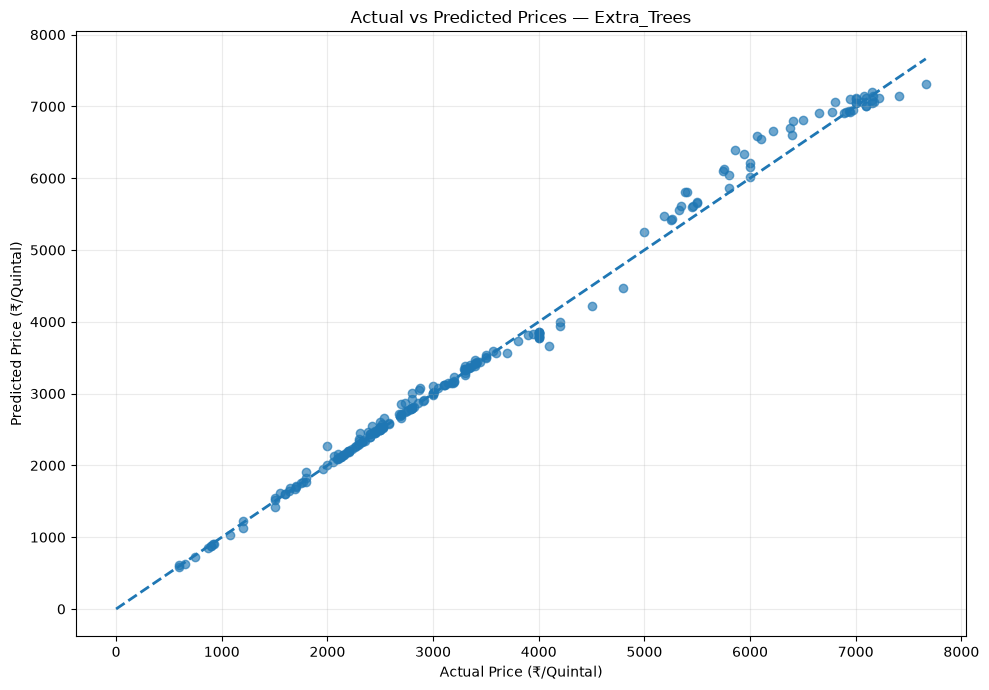


TEST-PERIOD FORECAST PERFORMANCE


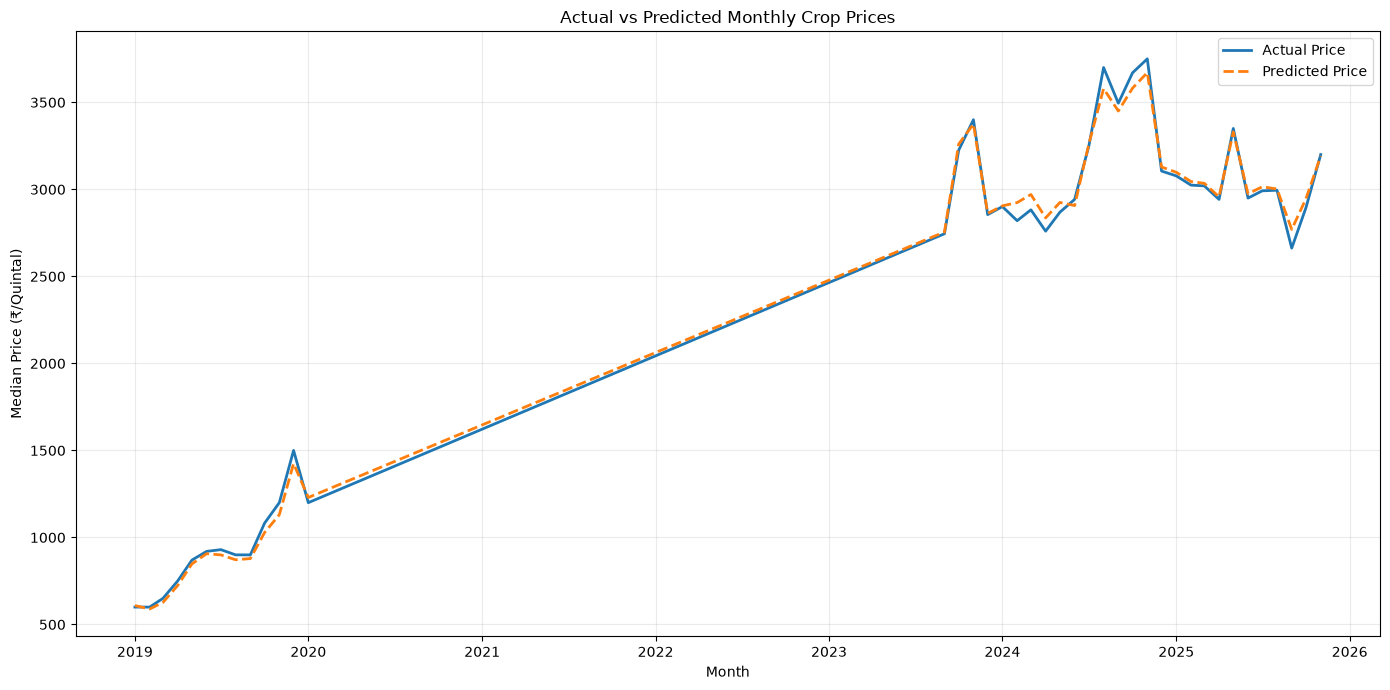


CROP-LEVEL MODEL PERFORMANCE


,Crop,Test_Observations,MAE,RMSE,MAPE,SMAPE,R2
0,Maize,27,5.1433,6.2910,0.2411,0.2414,0.9985
1,Wheat,27,7.4300,10.0768,0.2937,0.2932,0.9956
2,Rice,27,17.5650,21.3928,0.5344,0.5332,0.9842
3,Potato,13,31.6697,37.6859,3.1732,3.2273,0.9777
4,Jowar/Sorghum,27,77.6449,98.4869,2.7743,2.7289,0.9609
5,Banana,27,99.3600,129.4067,2.6666,2.7011,0.9447
6,Cotton,27,106.1605,144.7747,1.5128,1.5084,0.5611
7,Onion,27,94.7024,147.7556,3.2497,3.2431,0.9796
8,Groundnut,27,278.2082,309.1963,4.8432,4.7050,0.3812


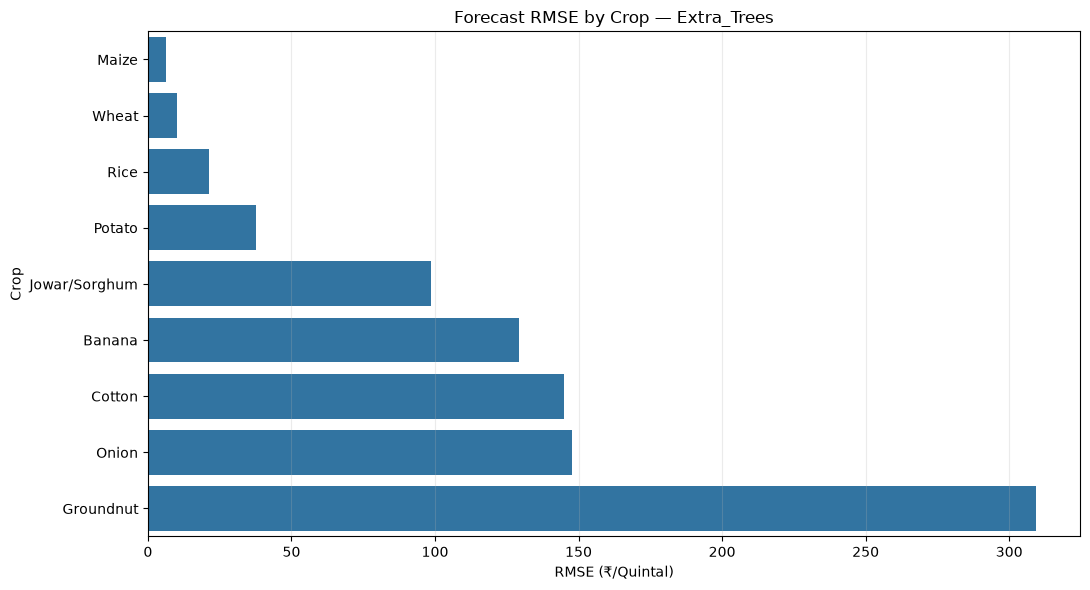

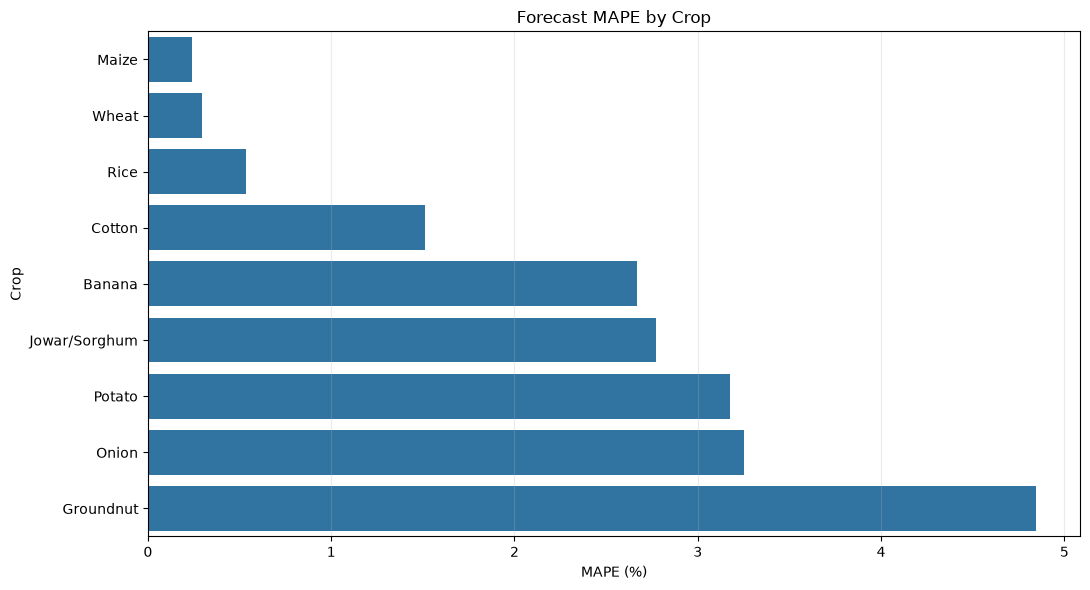

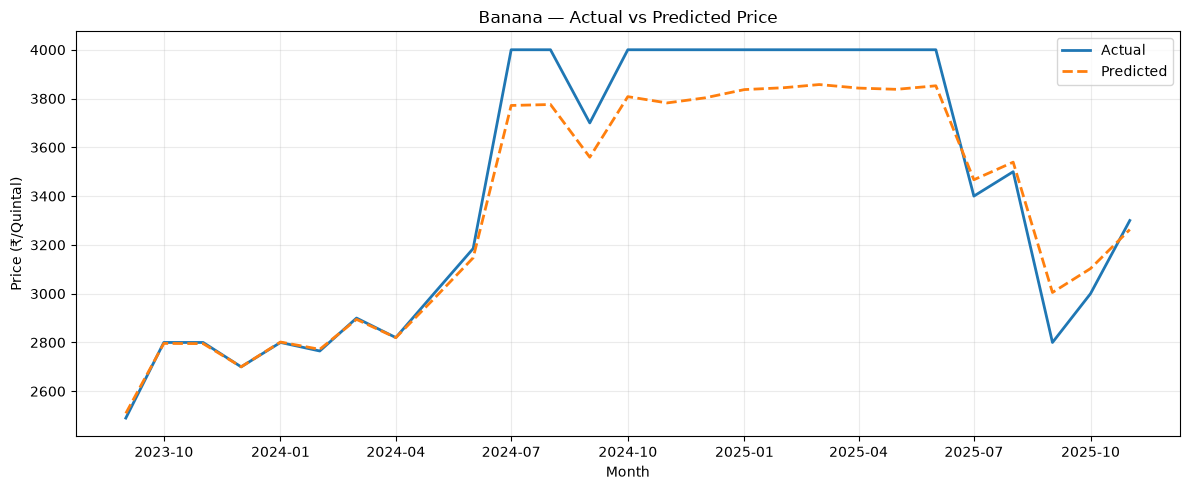

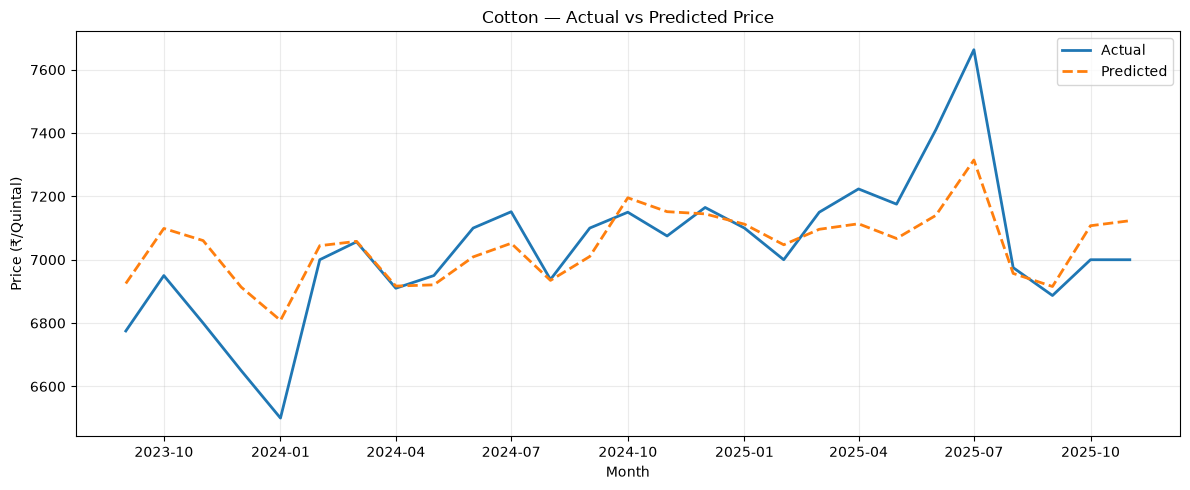

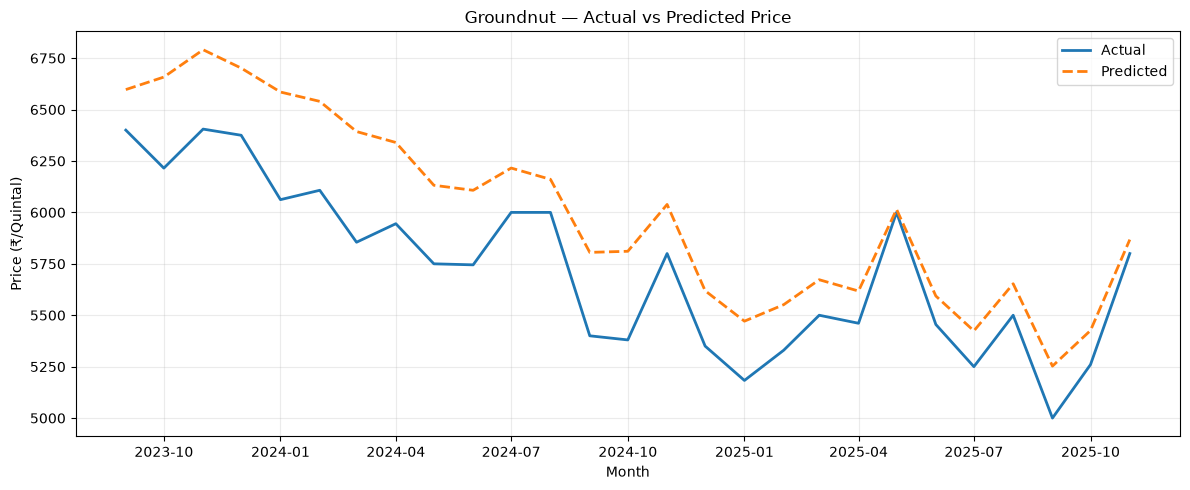

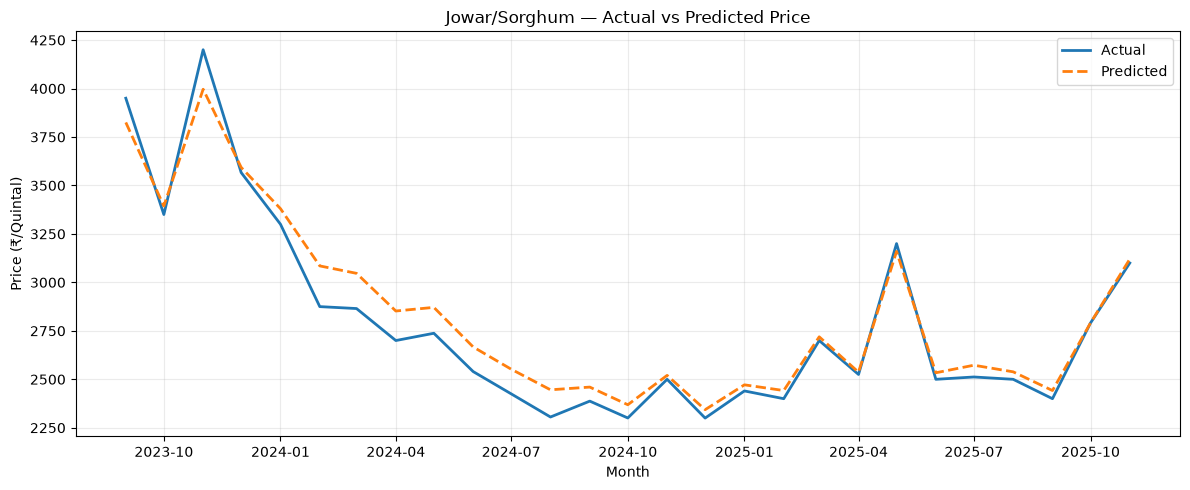

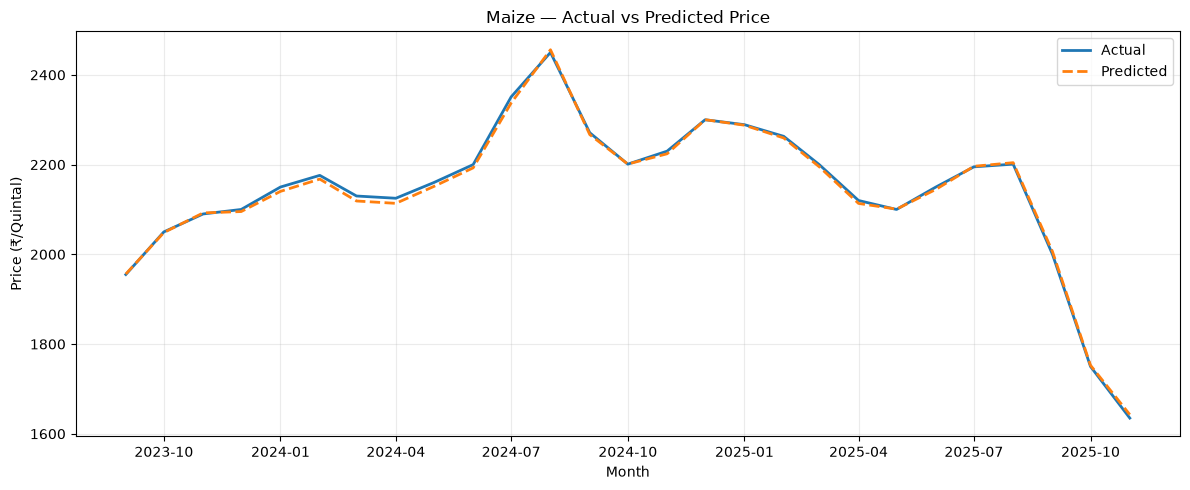

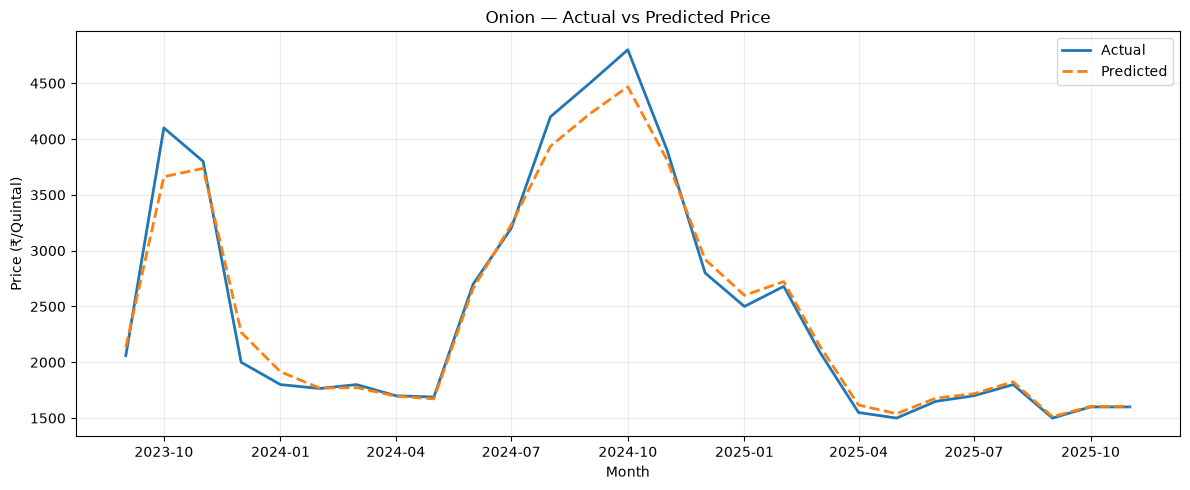

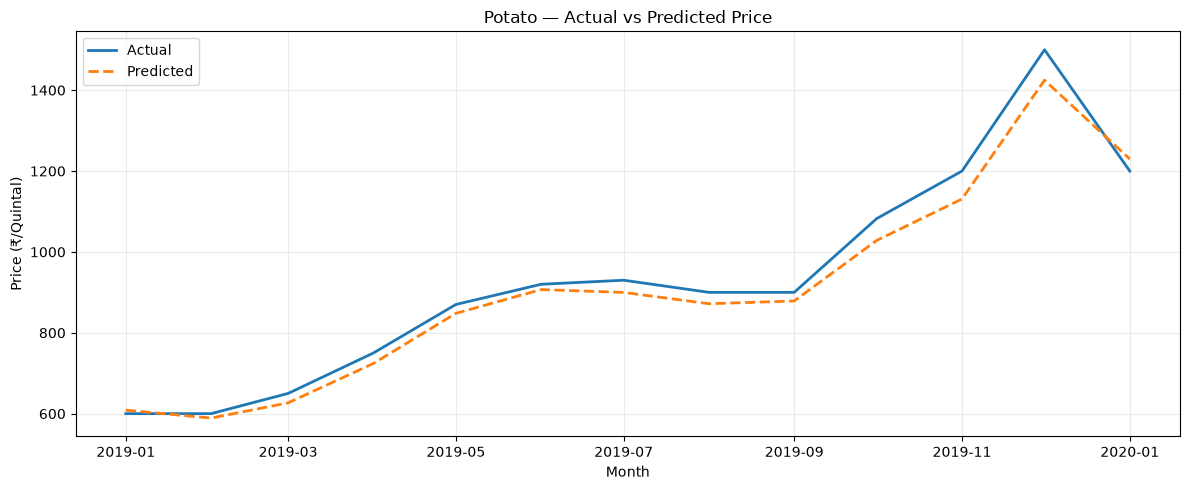

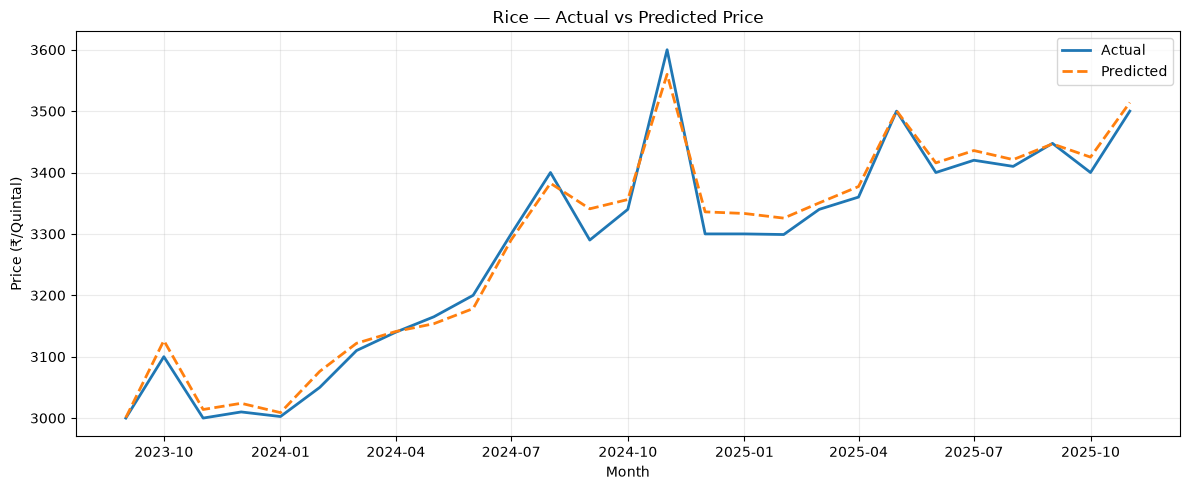

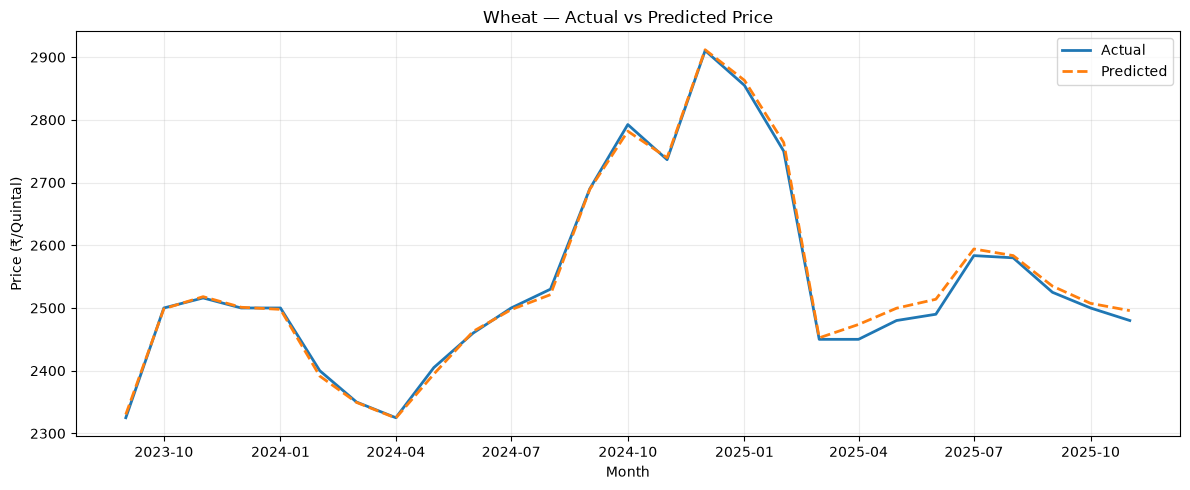


PRICE-BAND PERFORMANCE


,Price_Band,Test_Observations,MAE,RMSE,MAPE,SMAPE,R2
0,"< ₹2,000",31,34.3082,60.3071,2.5001,2.4845,0.9811
1,"₹2,000–₹5,000",145,53.4531,94.2938,1.6022,1.6060,0.9783
2,"₹5,000–₹7,500",52,188.0212,238.6706,3.1157,3.0419,0.8816
3,"₹7,500–₹10,000",1,348.1386,348.1386,4.5431,4.6487,NaN


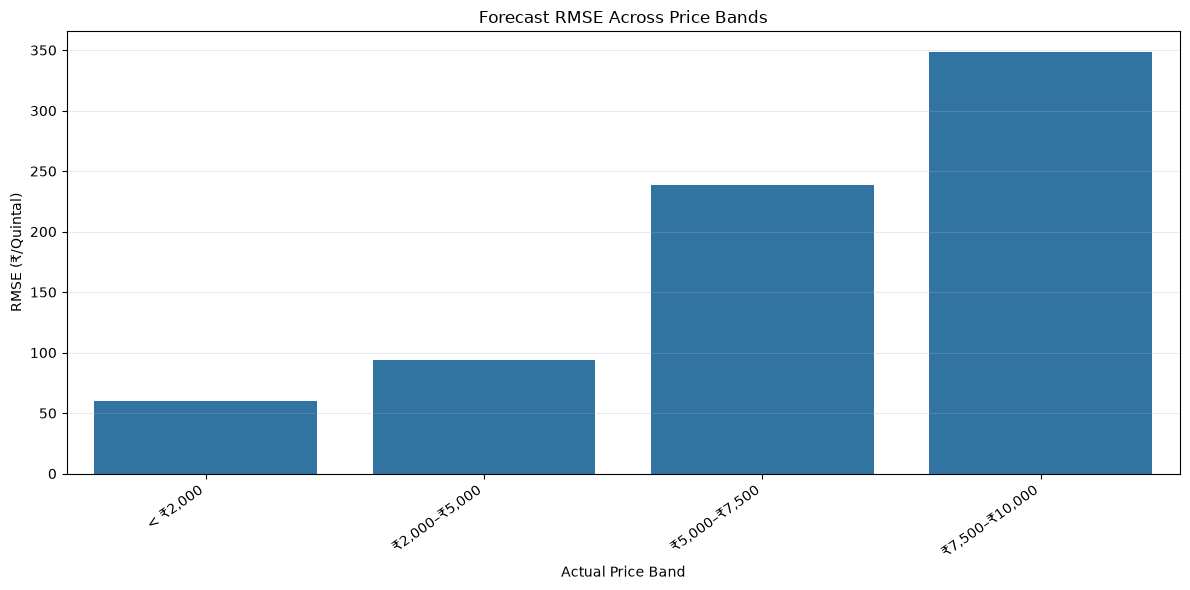


RESIDUAL ANALYSIS


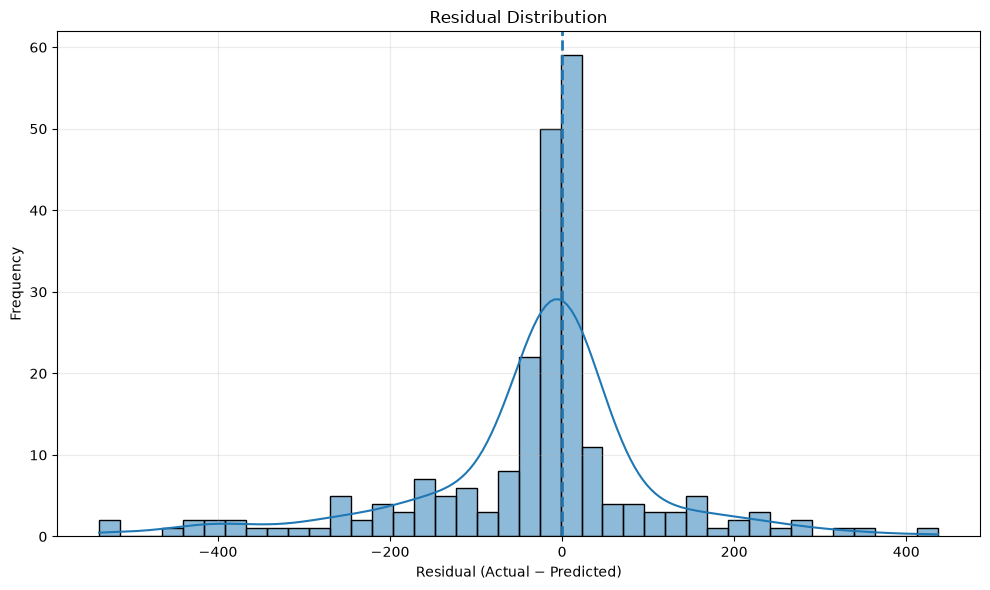

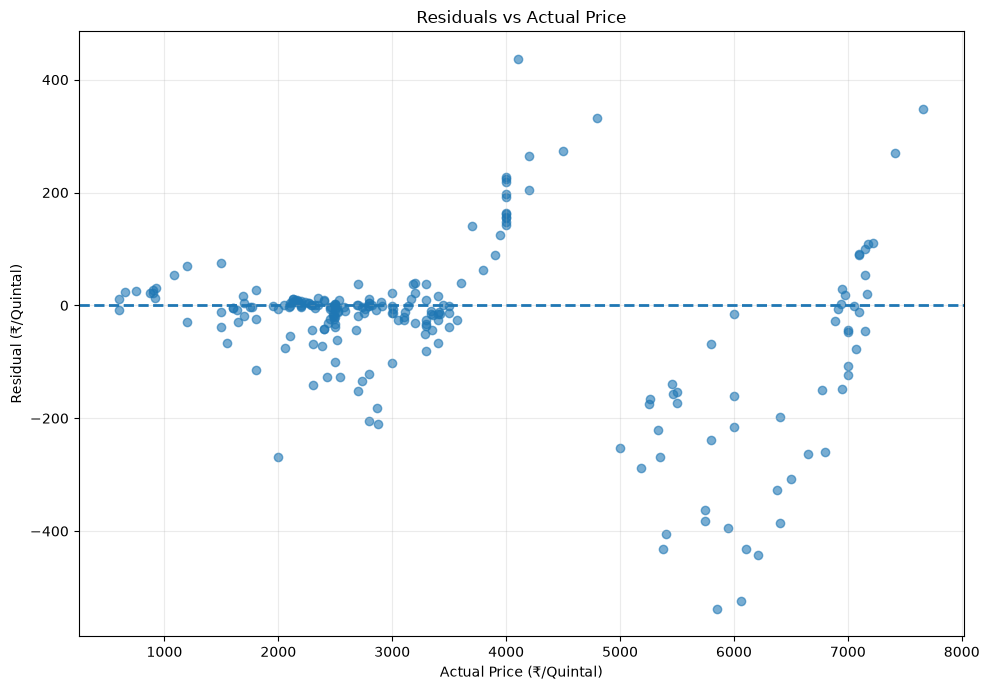

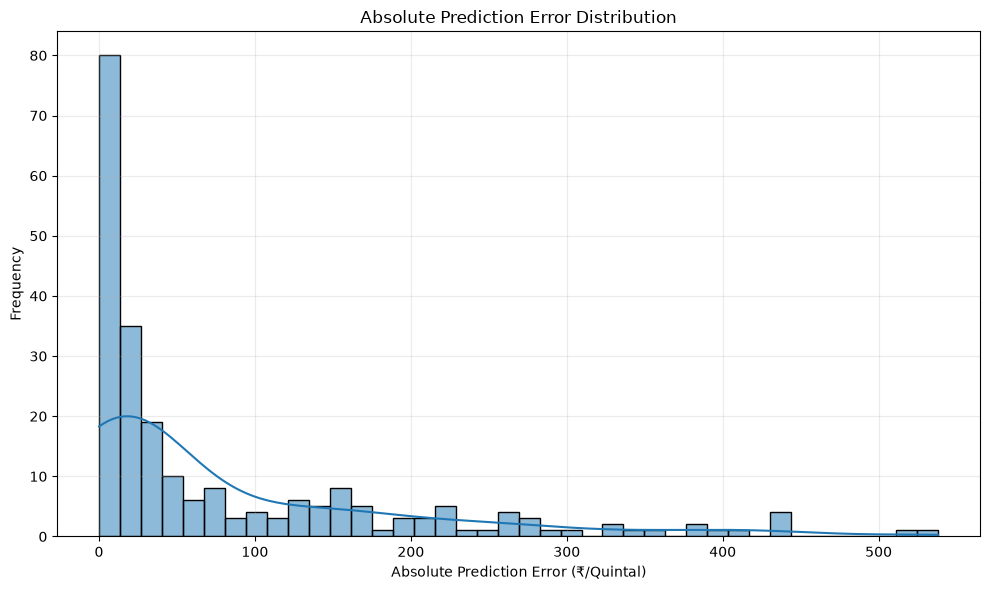

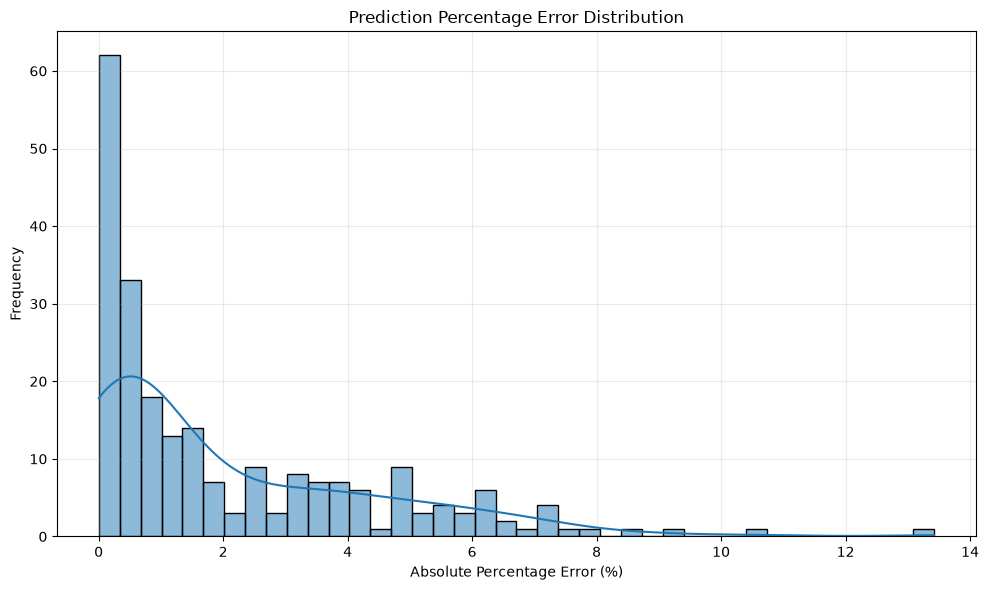


20 LARGEST PREDICTION ERRORS


,Crop,Month_Start,Actual_Price,Predicted_Price,Absolute_Error,Percentage_Error,Residual
60,Groundnut,2024-03-01,5855.00,6393.11,538.11,9.19,-538.11
58,Groundnut,2024-01-01,6062.00,6585.17,523.17,8.63,-523.17
55,Groundnut,2023-10-01,6215.25,6658.00,442.75,7.12,-442.75
136,Onion,2023-10-01,4100.00,3663.06,436.94,10.66,436.94
59,Groundnut,2024-02-01,6107.50,6539.83,432.33,7.08,-432.33
67,Groundnut,2024-10-01,5380.00,5810.98,430.98,8.01,-430.98
66,Groundnut,2024-09-01,5400.00,5805.57,405.57,7.51,-405.57
61,Groundnut,2024-04-01,5945.00,6339.96,394.96,6.64,-394.96
56,Groundnut,2023-11-01,6405.00,6790.77,385.77,6.02,-385.77
62,Groundnut,2024-05-01,5750.00,6131.85,381.85,6.64,-381.85



CROP PERFORMANCE SUMMARY

Lowest RMSE crop: Maize
RMSE: ₹6.29

Highest RMSE crop: Groundnut
RMSE: ₹309.20

INDEPENDENT PREDICTION ERROR CHECK

Mean residual: ₹-30.10
Median residual: ₹-6.18
Mean absolute error: ₹82.71
RMSE: ₹139.95
R²: 0.9938

MODEL EVALUATION COMPLETE

Best model:                 Extra_Trees
Test observations:         229
Number of crops:           9

MAE:                       ₹82.71
RMSE:                      ₹139.95
MAPE:                      2.08%
SMAPE:                     2.06%
R²:                        0.9938

Mean residual:             ₹-30.10
Median residual:           ₹-6.18

RMSE improvement vs naive: 69.03%
MAE improvement vs naive:  68.16%

Evaluation files saved:
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\outputs\evaluation\model_comparison_evaluation.csv
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\Food Price Forecasting\outputs\evaluation\crop_level_performance.csv
  ✓ d:\OneDrive\Documents\Desktop\Resume Projects\F

In [1]:
# ============================================================
# 06_MODEL_EVALUATION
# FOOD PRICE FORECASTING MODEL EVALUATION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# ============================================================
# 1. PROJECT PATHS
# ============================================================

PROJECT_ROOT = Path.cwd().parent

OUTPUT_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "forecasting"
)

EVALUATION_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "evaluation"
)

EVALUATION_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD FORECASTING OUTPUTS
# ============================================================

print("=" * 70)
print("FOOD PRICE FORECASTING")
print("MODEL EVALUATION")
print("=" * 70)

print("\nLoading forecasting outputs...")


model_comparison = pd.read_csv(
    OUTPUT_DIR / "model_comparison.csv"
)

crop_performance = pd.read_csv(
    OUTPUT_DIR / "crop_model_performance.csv"
)

price_band_performance = pd.read_csv(
    OUTPUT_DIR / "price_band_model_performance.csv"
)

test_predictions = pd.read_csv(
    OUTPUT_DIR / "test_predictions.csv"
)


test_predictions["Month_Start"] = pd.to_datetime(
    test_predictions["Month_Start"],
    errors="coerce"
)


test_predictions = (
    test_predictions
    .sort_values(
        ["Crop", "Month_Start"]
    )
    .reset_index(drop=True)
)


print("\nFiles loaded successfully.")

print(
    f"\nModel comparison rows:      {len(model_comparison):,}"
)

print(
    f"Crop performance rows:      {len(crop_performance):,}"
)

print(
    f"Price-band rows:            {len(price_band_performance):,}"
)

print(
    f"Test prediction rows:       {len(test_predictions):,}"
)


# ============================================================
# 3. VALIDATE REQUIRED COLUMNS
# ============================================================

required_prediction_columns = [
    "Crop",
    "Month_Start",
    "Actual_Price",
    "Predicted_Price",
    "Absolute_Error",
    "Percentage_Error"
]


missing_columns = [
    col
    for col in required_prediction_columns
    if col not in test_predictions.columns
]


if missing_columns:

    raise ValueError(
        f"Missing required prediction columns: "
        f"{missing_columns}"
    )


test_predictions = test_predictions.dropna(
    subset=[
        "Actual_Price",
        "Predicted_Price"
    ]
).copy()


# ============================================================
# 4. CALCULATE RESIDUALS
# ============================================================

test_predictions["Residual"] = (
    test_predictions["Actual_Price"]
    -
    test_predictions["Predicted_Price"]
)


test_predictions["Absolute_Residual"] = (
    np.abs(
        test_predictions["Residual"]
    )
)


test_predictions["Squared_Error"] = (
    test_predictions["Residual"] ** 2
)


# ============================================================
# 5. IDENTIFY BEST MACHINE LEARNING MODEL
# ============================================================

ml_comparison = model_comparison[
    model_comparison["Model"] != "Naive_Last_Month"
].copy()


ml_comparison = ml_comparison.sort_values(
    "RMSE",
    ascending=True
).reset_index(drop=True)


best_model_name = (
    ml_comparison
    .iloc[0]["Model"]
)


best_model_metrics = (
    ml_comparison
    .iloc[0]
)


print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)


print(
    f"\nBest machine learning model: "
    f"{best_model_name}"
)


print(
    f"MAE:   ₹{best_model_metrics['MAE']:,.2f}"
)

print(
    f"RMSE:  ₹{best_model_metrics['RMSE']:,.2f}"
)

print(
    f"MAPE:  {best_model_metrics['MAPE']:.2f}%"
)

print(
    f"SMAPE: {best_model_metrics['SMAPE']:.2f}%"
)

print(
    f"R²:    {best_model_metrics['R2']:.4f}"
)


# ============================================================
# 6. MODEL COMPARISON TABLE
# ============================================================

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)


display(
    model_comparison.round(4)
)


model_comparison.to_csv(
    EVALUATION_DIR
    / "model_comparison_evaluation.csv",
    index=False
)


# ============================================================
# 7. CALCULATE BASELINE IMPROVEMENT
# ============================================================

baseline_row = model_comparison[
    model_comparison["Model"]
    ==
    "Naive_Last_Month"
]


if len(baseline_row) > 0:

    baseline_rmse = (
        baseline_row.iloc[0]["RMSE"]
    )

    baseline_mae = (
        baseline_row.iloc[0]["MAE"]
    )

    best_rmse = (
        best_model_metrics["RMSE"]
    )

    best_mae = (
        best_model_metrics["MAE"]
    )

    rmse_improvement = (
        (
            baseline_rmse
            -
            best_rmse
        )
        /
        baseline_rmse
        *
        100
    )

    mae_improvement = (
        (
            baseline_mae
            -
            best_mae
        )
        /
        baseline_mae
        *
        100
    )

    print("\n" + "=" * 70)
    print("IMPROVEMENT OVER NAIVE BASELINE")
    print("=" * 70)

    print(
        f"\nBaseline RMSE: "
        f"₹{baseline_rmse:,.2f}"
    )

    print(
        f"Best model RMSE: "
        f"₹{best_rmse:,.2f}"
    )

    print(
        f"RMSE improvement: "
        f"{rmse_improvement:.2f}%"
    )

    print(
        f"\nBaseline MAE: "
        f"₹{baseline_mae:,.2f}"
    )

    print(
        f"Best model MAE: "
        f"₹{best_mae:,.2f}"
    )

    print(
        f"MAE improvement: "
        f"{mae_improvement:.2f}%"
    )

else:

    rmse_improvement = np.nan
    mae_improvement = np.nan


# ============================================================
# 8. ACTUAL VS PREDICTED SCATTER PLOT
# ============================================================

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED PRICE")
print("=" * 70)


plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"],
    alpha=0.65
)


max_value = max(
    test_predictions["Actual_Price"].max(),
    test_predictions["Predicted_Price"].max()
)


plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Price (₹/Quintal)"
)

plt.ylabel(
    "Predicted Price (₹/Quintal)"
)

plt.title(
    f"Actual vs Predicted Prices — {best_model_name}"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "actual_vs_predicted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 9. OVERALL TEST-PERIOD TIME SERIES
# ============================================================

print("\n" + "=" * 70)
print("TEST-PERIOD FORECAST PERFORMANCE")
print("=" * 70)


overall_monthly = (
    test_predictions
    .groupby("Month_Start")
    .agg(
        Actual_Price=("Actual_Price", "median"),
        Predicted_Price=("Predicted_Price", "median")
    )
    .reset_index()
)


plt.figure(
    figsize=(14, 7)
)


plt.plot(
    overall_monthly["Month_Start"],
    overall_monthly["Actual_Price"],
    linewidth=2,
    label="Actual Price"
)


plt.plot(
    overall_monthly["Month_Start"],
    overall_monthly["Predicted_Price"],
    linewidth=2,
    linestyle="--",
    label="Predicted Price"
)


plt.xlabel(
    "Month"
)

plt.ylabel(
    "Median Price (₹/Quintal)"
)

plt.title(
    "Actual vs Predicted Monthly Crop Prices"
)


plt.legend()


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "overall_actual_vs_predicted_time_series.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 10. CROP-LEVEL PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("CROP-LEVEL MODEL PERFORMANCE")
print("=" * 70)


display(
    crop_performance.round(4)
)


crop_performance.to_csv(
    EVALUATION_DIR
    / "crop_level_performance.csv",
    index=False
)


# ============================================================
# 11. CROP-LEVEL RMSE
# ============================================================

plt.figure(
    figsize=(11, 6)
)


crop_plot = (
    crop_performance
    .sort_values("RMSE")
)


sns.barplot(
    data=crop_plot,
    x="RMSE",
    y="Crop"
)


plt.xlabel(
    "RMSE (₹/Quintal)"
)

plt.ylabel(
    "Crop"
)

plt.title(
    f"Forecast RMSE by Crop — {best_model_name}"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "crop_rmse.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 12. CROP-LEVEL MAPE
# ============================================================

plt.figure(
    figsize=(11, 6)
)


crop_mape_plot = (
    crop_performance
    .sort_values("MAPE")
)


sns.barplot(
    data=crop_mape_plot,
    x="MAPE",
    y="Crop"
)


plt.xlabel(
    "MAPE (%)"
)

plt.ylabel(
    "Crop"
)

plt.title(
    "Forecast MAPE by Crop"
)


plt.grid(
    axis="x",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "crop_mape.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 13. CROP-WISE ACTUAL VS PREDICTED
# ============================================================

crop_prediction_summary = (
    test_predictions
    .groupby(
        ["Crop", "Month_Start"]
    )
    .agg(
        Actual_Price=("Actual_Price", "median"),
        Predicted_Price=("Predicted_Price", "median")
    )
    .reset_index()
)


crop_prediction_summary.to_csv(
    EVALUATION_DIR
    / "crop_monthly_predictions.csv",
    index=False
)


for crop in sorted(
    crop_prediction_summary["Crop"].unique()
):

    crop_data = crop_prediction_summary[
        crop_prediction_summary["Crop"] == crop
    ].copy()

    plt.figure(
        figsize=(12, 5)
    )

    plt.plot(
        crop_data["Month_Start"],
        crop_data["Actual_Price"],
        linewidth=2,
        label="Actual"
    )

    plt.plot(
        crop_data["Month_Start"],
        crop_data["Predicted_Price"],
        linewidth=2,
        linestyle="--",
        label="Predicted"
    )

    plt.title(
        f"{crop} — Actual vs Predicted Price"
    )

    plt.xlabel(
        "Month"
    )

    plt.ylabel(
        "Price (₹/Quintal)"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    safe_crop_name = (
        crop
        .replace("/", "_")
        .replace(" ", "_")
    )

    plt.savefig(
        EVALUATION_DIR
        / f"{safe_crop_name}_actual_vs_predicted.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 14. PRICE-BAND PERFORMANCE
# ============================================================

print("\n" + "=" * 70)
print("PRICE-BAND PERFORMANCE")
print("=" * 70)


display(
    price_band_performance.round(4)
)


price_band_performance.to_csv(
    EVALUATION_DIR
    / "price_band_performance.csv",
    index=False
)


# ============================================================
# 15. PRICE-BAND RMSE
# ============================================================

plt.figure(
    figsize=(12, 6)
)


sns.barplot(
    data=price_band_performance,
    x="Price_Band",
    y="RMSE"
)


plt.xlabel(
    "Actual Price Band"
)

plt.ylabel(
    "RMSE (₹/Quintal)"
)

plt.title(
    "Forecast RMSE Across Price Bands"
)


plt.xticks(
    rotation=35,
    ha="right"
)


plt.grid(
    axis="y",
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "price_band_rmse.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 16. RESIDUAL DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("RESIDUAL ANALYSIS")
print("=" * 70)


plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    test_predictions["Residual"],
    bins=40,
    kde=True
)


plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Residual (Actual − Predicted)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Residual Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 17. RESIDUALS VS ACTUAL PRICE
# ============================================================

plt.figure(
    figsize=(10, 7)
)


plt.scatter(
    test_predictions["Actual_Price"],
    test_predictions["Residual"],
    alpha=0.60
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)


plt.xlabel(
    "Actual Price (₹/Quintal)"
)

plt.ylabel(
    "Residual (₹/Quintal)"
)

plt.title(
    "Residuals vs Actual Price"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "residuals_vs_actual.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 18. ABSOLUTE ERROR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    test_predictions["Absolute_Error"],
    bins=40,
    kde=True
)


plt.xlabel(
    "Absolute Prediction Error (₹/Quintal)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Absolute Prediction Error Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "absolute_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 19. PERCENTAGE ERROR DISTRIBUTION
# ============================================================

percentage_error_clean = (
    test_predictions["Percentage_Error"]
    .replace(
        [np.inf, -np.inf],
        np.nan
    )
    .dropna()
)


percentage_error_clean = (
    percentage_error_clean[
        percentage_error_clean <= 100
    ]
)


plt.figure(
    figsize=(10, 6)
)


sns.histplot(
    percentage_error_clean,
    bins=40,
    kde=True
)


plt.xlabel(
    "Absolute Percentage Error (%)"
)

plt.ylabel(
    "Frequency"
)

plt.title(
    "Prediction Percentage Error Distribution"
)


plt.grid(
    alpha=0.25
)


plt.tight_layout()


plt.savefig(
    EVALUATION_DIR
    / "percentage_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()


# ============================================================
# 20. LARGEST PREDICTION ERRORS
# ============================================================

print("\n" + "=" * 70)
print("20 LARGEST PREDICTION ERRORS")
print("=" * 70)


largest_errors = (
    test_predictions
    .sort_values(
        "Absolute_Error",
        ascending=False
    )
    .head(20)
    [
        [
            "Crop",
            "Month_Start",
            "Actual_Price",
            "Predicted_Price",
            "Absolute_Error",
            "Percentage_Error",
            "Residual"
        ]
    ]
)


display(
    largest_errors.round(2)
)


largest_errors.to_csv(
    EVALUATION_DIR
    / "largest_prediction_errors.csv",
    index=False
)


# ============================================================
# 21. BEST AND WORST CROP PERFORMANCE
# ============================================================

best_crop_by_rmse = (
    crop_performance
    .sort_values("RMSE")
    .iloc[0]
)


worst_crop_by_rmse = (
    crop_performance
    .sort_values("RMSE", ascending=False)
    .iloc[0]
)


print("\n" + "=" * 70)
print("CROP PERFORMANCE SUMMARY")
print("=" * 70)


print(
    f"\nLowest RMSE crop: "
    f"{best_crop_by_rmse['Crop']}"
)

print(
    f"RMSE: "
    f"₹{best_crop_by_rmse['RMSE']:,.2f}"
)


print(
    f"\nHighest RMSE crop: "
    f"{worst_crop_by_rmse['Crop']}"
)

print(
    f"RMSE: "
    f"₹{worst_crop_by_rmse['RMSE']:,.2f}"
)


# ============================================================
# 22. ERROR SUMMARY
# ============================================================

mean_residual = (
    test_predictions["Residual"].mean()
)


median_residual = (
    test_predictions["Residual"].median()
)


mean_absolute_error_value = (
    test_predictions["Absolute_Error"].mean()
)


rmse_value = np.sqrt(
    np.mean(
        test_predictions["Residual"] ** 2
    )
)


r2_value = r2_score(
    test_predictions["Actual_Price"],
    test_predictions["Predicted_Price"]
)


print("\n" + "=" * 70)
print("INDEPENDENT PREDICTION ERROR CHECK")
print("=" * 70)


print(
    f"\nMean residual: "
    f"₹{mean_residual:,.2f}"
)


print(
    f"Median residual: "
    f"₹{median_residual:,.2f}"
)


print(
    f"Mean absolute error: "
    f"₹{mean_absolute_error_value:,.2f}"
)


print(
    f"RMSE: "
    f"₹{rmse_value:,.2f}"
)


print(
    f"R²: "
    f"{r2_value:.4f}"
)


# ============================================================
# 23. SAVE RESIDUAL DATA
# ============================================================

residual_output = test_predictions[
    [
        "Crop",
        "Month_Start",
        "Actual_Price",
        "Predicted_Price",
        "Residual",
        "Absolute_Residual",
        "Percentage_Error"
    ]
].copy()


residual_output.to_csv(
    EVALUATION_DIR
    / "residual_analysis.csv",
    index=False
)


# ============================================================
# 24. SAVE EVALUATION SUMMARY
# ============================================================

evaluation_summary = pd.DataFrame(
    {
        "Metric": [
            "Best Model",
            "Test Observations",
            "Number of Crops",
            "MAE",
            "RMSE",
            "MAPE",
            "SMAPE",
            "R2",
            "Mean Residual",
            "Median Residual",
            "RMSE Improvement vs Naive",
            "MAE Improvement vs Naive"
        ],
        "Value": [
            best_model_name,
            len(test_predictions),
            test_predictions["Crop"].nunique(),
            best_model_metrics["MAE"],
            best_model_metrics["RMSE"],
            best_model_metrics["MAPE"],
            best_model_metrics["SMAPE"],
            best_model_metrics["R2"],
            mean_residual,
            median_residual,
            rmse_improvement,
            mae_improvement
        ]
    }
)


evaluation_summary.to_csv(
    EVALUATION_DIR
    / "evaluation_summary.csv",
    index=False
)


# ============================================================
# 25. FINAL EVALUATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("MODEL EVALUATION COMPLETE")
print("=" * 70)


print(
    f"\nBest model:                 "
    f"{best_model_name}"
)


print(
    f"Test observations:         "
    f"{len(test_predictions):,}"
)


print(
    f"Number of crops:           "
    f"{test_predictions['Crop'].nunique()}"
)


print(
    f"\nMAE:                       "
    f"₹{best_model_metrics['MAE']:,.2f}"
)


print(
    f"RMSE:                      "
    f"₹{best_model_metrics['RMSE']:,.2f}"
)


print(
    f"MAPE:                      "
    f"{best_model_metrics['MAPE']:.2f}%"
)


print(
    f"SMAPE:                     "
    f"{best_model_metrics['SMAPE']:.2f}%"
)


print(
    f"R²:                        "
    f"{best_model_metrics['R2']:.4f}"
)


print(
    f"\nMean residual:             "
    f"₹{mean_residual:,.2f}"
)


print(
    f"Median residual:           "
    f"₹{median_residual:,.2f}"
)


if not np.isnan(rmse_improvement):

    print(
        f"\nRMSE improvement vs naive: "
        f"{rmse_improvement:.2f}%"
    )

    print(
        f"MAE improvement vs naive:  "
        f"{mae_improvement:.2f}%"
    )


print("\nEvaluation files saved:")

print(
    f"  ✓ {EVALUATION_DIR / 'model_comparison_evaluation.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'crop_level_performance.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'price_band_performance.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'crop_monthly_predictions.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'largest_prediction_errors.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'residual_analysis.csv'}"
)

print(
    f"  ✓ {EVALUATION_DIR / 'evaluation_summary.csv'}"
)


print("\nEvaluation charts saved in:")

print(
    f"  ✓ {EVALUATION_DIR}"
)


print("\n" + "=" * 70)
print("READY FOR FINAL FORECASTING / PROJECT INSIGHTS")
print("=" * 70)